# **PROJECT PEMBELAJARAN MESIN (FINAL)**

## Perbandingan Metode Machine Learning Klasik dan Deep Learning untuk Pengenalan Emosi Multimodal Berbasis Fitur Audio dan Teks pada Dataset MELD

#### **KELOMPOK 3**
#### 1. Tazkia Caecaria Marchanda (24031554002)
#### 2. Hafidzah Maulidya Indi Wiyana (24031554021)
#### 3. Alya Ummi Faricha (24031554123)

#### **Kelas: 2024E**

#### Dosen Pengampu: Riskyana Dewi Intan Puspitasari, M.Kom.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

MELD_PATH  = '/content/drive/MyDrive/UAS ML/MELD.Raw'
TRAIN_VID  = os.path.join(MELD_PATH, 'train_splits')
DEV_VID    = os.path.join(MELD_PATH, 'dev_splits_complete')
TEST_VID   = os.path.join(MELD_PATH, 'output_repeated_splits_test')

for name, path in [('train_splits', TRAIN_VID),
                   ('dev_splits_complete', DEV_VID),
                   ('output_repeated_splits_test', TEST_VID)]:
    if os.path.exists(path):
        files = os.listdir(path)
        mp4s  = [f for f in files if f.endswith('.mp4') and not f.startswith('._')]
        print(f"{name}: {len(mp4s)} file mp4 valid")
    else:
        print(f"{name}: folder tidak ada")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train_splits: 13632 file mp4 valid
dev_splits_complete: 1197 file mp4 valid
output_repeated_splits_test: 2801 file mp4 valid


In [ ]:
import subprocess, os
for fname, expected_folder in [
    ('train.tar.gz', '/content/train_splits'),
    ('dev.tar.gz',   '/content/dev_splits_complete')
]:
    tar_path = os.path.join(MELD_PATH, fname)
    print(f"Ekstrak {fname} → /content/ ...")
    print(f"Ukuran file: {os.path.getsize(tar_path)/1024**3:.2f} GB")

    result = subprocess.run(
        ['tar', '-xzf', tar_path, '-C', '/content/'],
        capture_output=True, text=True
    )

    if result.returncode == 0:
        files = [f for f in os.listdir(expected_folder)
                 if f.endswith('.mp4') and not f.startswith('._')]
        print(f"Selesai! {len(files)} file mp4 valid\n")
    else:
        print(f"Error: {result.stderr}\n")

Ekstrak train.tar.gz → /content/ ...
Ukuran file: 7.32 GB
✓ Selesai! 9989 file mp4 valid

Ekstrak dev.tar.gz → /content/ ...
Ukuran file: 0.72 GB
✓ Selesai! 1112 file mp4 valid



In [ ]:
!pip install -q librosa sentence-transformers praat-parselmouth seaborn umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 40.9 MB/s eta 0:00:00


In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import parselmouth
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew, kurtosis
warnings.filterwarnings('ignore')

EMOTION_PALETTE = {
    'neutral' : '#7f8c8d',
    'surprise': '#f39c12',
    'fear'    : '#8e44ad',
    'sadness' : '#2980b9',
    'joy'     : '#27ae60',
    'disgust' : '#c0392b',
    'anger'   : '#e74c3c',
}

In [ ]:
df_train = pd.read_csv(os.path.join(MELD_PATH, 'train_sent_emo.csv'))
df_dev   = pd.read_csv(os.path.join(MELD_PATH, 'dev_sent_emo.csv'))
df_test  = pd.read_csv(os.path.join(MELD_PATH, 'test_sent_emo.csv'))

for df in [df_train, df_dev, df_test]:
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Kolom df_train :", df_train.columns.tolist())

Kolom df_train : ['sr_no.', 'utterance', 'speaker', 'emotion', 'sentiment', 'dialogue_id', 'utterance_id', 'season', 'episode', 'starttime', 'endtime']


In [ ]:
df_emotion_sample = df_train.groupby('emotion').head(1)[['dialogue_id', 'utterance_id', 'utterance', 'emotion']]
df_emotion_sample

,dialogue_id,utterance_id,utterance,emotion
0,0,0,also I was the point person on my companys tr...,neutral
4,0,4,My duties? All right.,surprise
10,0,10,No dont I beg of you!,fear
15,1,1,You know? Forget it!,sadness
23,2,2,Do I ever.,joy
27,2,6,Just coffee! Where are we gonna hang out now?,disgust
67,6,5,"Oh no-no-no, give me some specifics.",anger


Visualisasi Distribusi Label

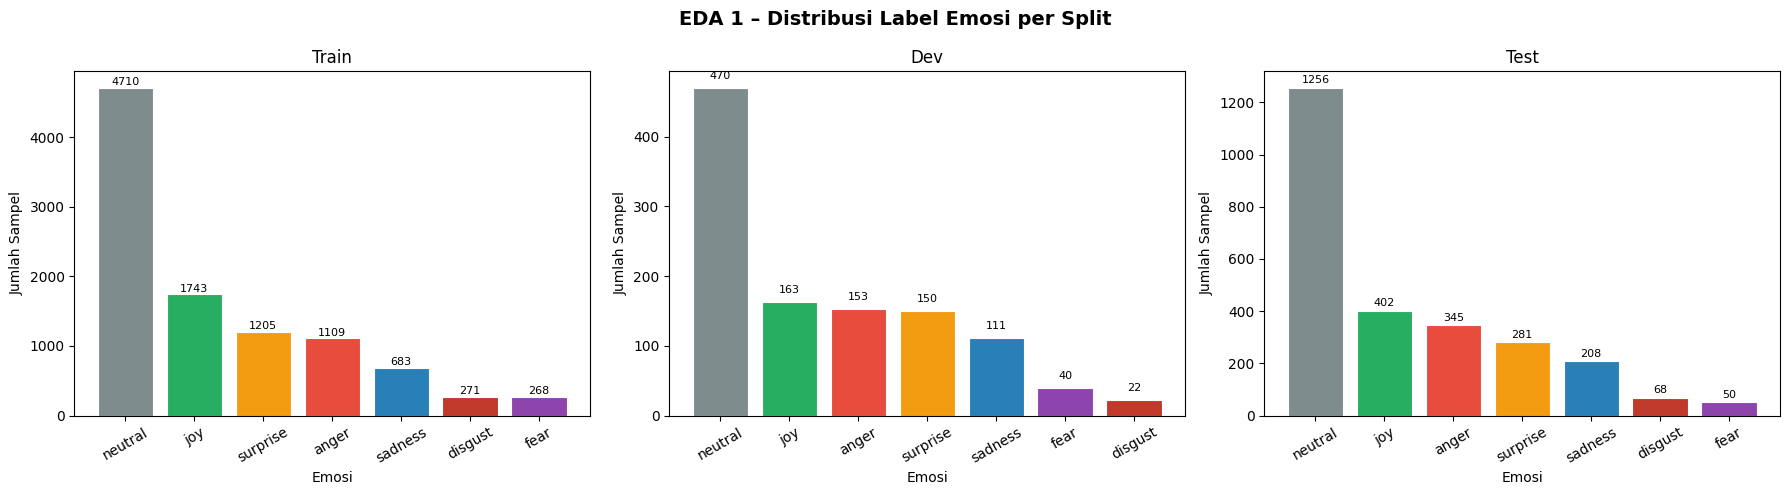

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA 1 – Distribusi Label Emosi per Split', fontsize=14, fontweight='bold')

for ax, (df, title) in zip(axes, [(df_train,'Train'), (df_dev,'Dev'), (df_test,'Test')]):
    counts = df['emotion'].value_counts()
    colors = [EMOTION_PALETTE.get(e, '#999') for e in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Emosi')
    ax.set_ylabel('Jumlah Sampel')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 10, str(v),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/eda1_label_distribution.png', dpi=150)
plt.show()

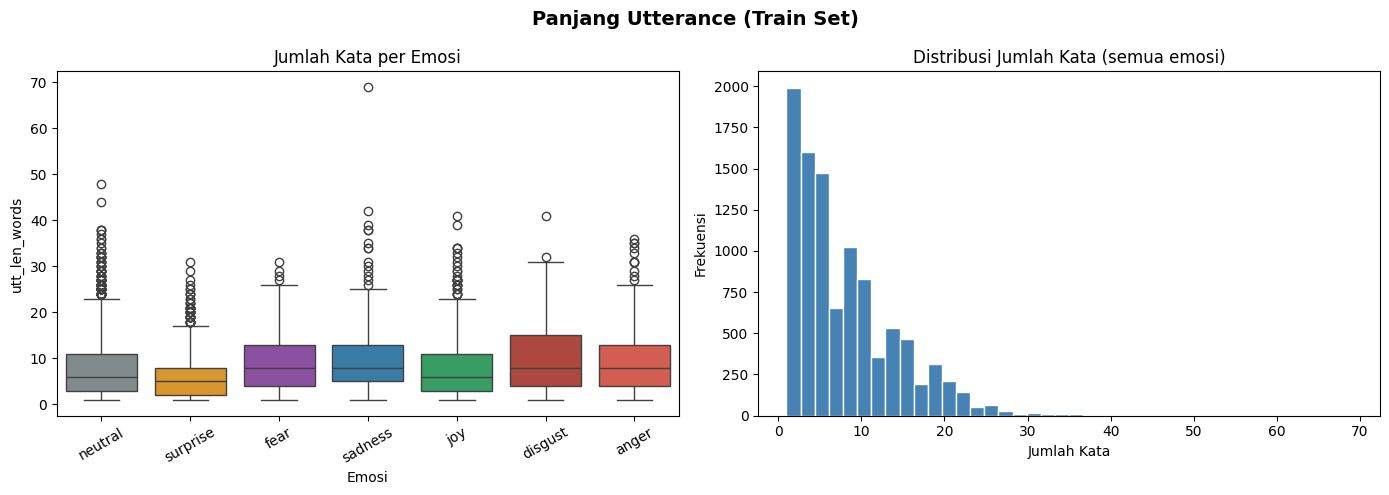


Stat panjang kata per emosi (train):
           count  mean   std  min  25%  50%   75%   max
emotion                                                
anger     1109.0  9.15  6.35  1.0  4.0  8.0  13.0  36.0
disgust    271.0  9.95  7.08  1.0  4.0  8.0  15.0  41.0
fear       268.0  9.09  6.22  1.0  4.0  8.0  13.0  31.0
joy       1743.0  7.75  6.06  1.0  3.0  6.0  11.0  41.0
neutral   4710.0  7.79  6.20  1.0  3.0  6.0  11.0  48.0
sadness    683.0  9.95  7.10  1.0  5.0  8.0  13.0  69.0
surprise  1205.0  6.02  5.03  1.0  2.0  5.0   8.0  31.0


In [ ]:
df_train['utt_len_chars'] = df_train['utterance'].str.len()
df_train['utt_len_words'] = df_train['utterance'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Panjang Utterance (Train Set)', fontsize=14, fontweight='bold')

sns.boxplot(data=df_train, x='emotion', y='utt_len_words',
            palette=EMOTION_PALETTE, ax=axes[0])
axes[0].set_title('Jumlah Kata per Emosi')
axes[0].set_xlabel('Emosi'); axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(df_train['utt_len_words'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribusi Jumlah Kata (semua emosi)')
axes[1].set_xlabel('Jumlah Kata'); axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('/content/eda2_utterance_length.png', dpi=150)
plt.show()

print("\nStat panjang kata per emosi (train):")
print(df_train.groupby('emotion')['utt_len_words'].describe().round(2))

In [ ]:
#mendefinisikan
TRAIN_VID = '/content/train_splits'
DEV_VID   = '/content/dev_splits_complete'
TEST_VID  = '/content/output_repeated_splits_test'

def get_video_path(row, vid_folder):
    fname = f"dia{row['dialogue_id']}_utt{row['utterance_id']}.mp4"
    return os.path.join(vid_folder, fname)

In [ ]:
def extract_audio_from_video(video_path, sr=16000):
    y, _ = librosa.load(video_path, sr=sr, mono=True)
    return y, sr

def extract_mfcc_features(y, sr, n_mfcc=13):
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i, mat in enumerate([mfcc, delta, delta2]):
        prefix = ['mfcc', 'delta', 'delta2'][i]
        for j in range(n_mfcc):
            feats[f'{prefix}_{j}_mean'] = np.mean(mat[j])
            feats[f'{prefix}_{j}_std']  = np.std(mat[j])
    return feats   # 78 fitur

def extract_zcr_features(y):
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    return {
        'zcr_mean' : np.mean(zcr),
        'zcr_std'  : np.std(zcr),
        'zcr_skew' : skew(zcr),
        'zcr_kurt' : kurtosis(zcr),
    }

def extract_rms_features(y):
    rms = librosa.feature.rms(y=y)[0]
    return {
        'rms_mean'          : np.mean(rms),
        'rms_std'           : np.std(rms),
        'rms_skew'          : skew(rms),
        'rms_kurt'          : kurtosis(rms),
        'rms_dynamic_range' : np.max(rms) - np.min(rms),
    }

def extract_pitch_features(y, sr):
    sound  = parselmouth.Sound(y, sampling_frequency=sr)
    pitch  = sound.to_pitch()
    f0     = pitch.selected_array['frequency']
    voiced = f0[f0 > 0]   # hapus frame unvoiced (f0 = 0)

    if len(voiced) == 0:
        return {k: 0.0 for k in
                ['pitch_mean','pitch_std','pitch_min','pitch_max',
                 'pitch_range','pitch_median','pitch_voiced_ratio']}
    return {
        'pitch_mean'         : np.mean(voiced),
        'pitch_std'          : np.std(voiced),
        'pitch_min'          : np.min(voiced),
        'pitch_max'          : np.max(voiced),
        'pitch_range'        : np.max(voiced) - np.min(voiced),
        'pitch_median'       : np.median(voiced),
        'pitch_voiced_ratio' : len(voiced) / len(f0) if len(f0) > 0 else 0.0,
    }

def extract_all_audio_features(video_path, sr=16000):
    try:
        y, sr = extract_audio_from_video(video_path, sr)
        feats = {}
        feats.update(extract_mfcc_features(y, sr))
        feats.update(extract_zcr_features(y))
        feats.update(extract_rms_features(y))
        feats.update(extract_pitch_features(y, sr))
        feats['audio_ok'] = 1
    except Exception as e:
        # Jika file tidak ada / rusak → isi NaN
        feats = {'audio_ok': 0}
    return feats

In [ ]:
AUDIO_CACHE = {
    'train': os.path.join(MELD_PATH, 'audio_feats_train.csv'),
    'dev'  : os.path.join(MELD_PATH, 'audio_feats_dev.csv'),
    'test' : os.path.join(MELD_PATH, 'audio_feats_test.csv'),
}

def build_audio_features(df, vid_folder, cache_path, split_name):
    if os.path.exists(cache_path):
        print(f"[{split_name}] Cache ditemukan → load dari {cache_path}")
        return pd.read_csv(cache_path)

    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Audio {split_name}"):
        vpath = get_video_path(row, vid_folder)
        feats = extract_all_audio_features(vpath)
        feats['dialogue_id']   = row['dialogue_id']
        feats['utterance_id']  = row['utterance_id']
        rows.append(feats)

    feat_df = pd.DataFrame(rows)
    feat_df.to_csv(cache_path, index=False)
    print(f"[{split_name}] Selesai! {len(feat_df)} baris, disimpan ke {cache_path}")
    return feat_df
audio_train = build_audio_features(df_train, TRAIN_VID, AUDIO_CACHE['train'], 'Train')
audio_dev   = build_audio_features(df_dev,   DEV_VID,   AUDIO_CACHE['dev'],   'Dev')
audio_test  = build_audio_features(df_test,  TEST_VID,  AUDIO_CACHE['test'],  'Test')

[Train] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_train.csv
[Dev] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_dev.csv
[Test] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_test.csv


In [ ]:
audio_train = build_audio_features(df_train, TRAIN_VID, AUDIO_CACHE['train'], 'Train')
audio_dev   = build_audio_features(df_dev,   DEV_VID,   AUDIO_CACHE['dev'],   'Dev')
audio_test  = build_audio_features(df_test,  TEST_VID,  AUDIO_CACHE['test'],  'Test')

[Train] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_train.csv
[Dev] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_dev.csv
[Test] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_test.csv


Model Audio Only

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

MELD_PATH = '/content/drive/MyDrive/UAS ML/MELD.Raw'
AUDIO_CACHE = {
    'train': os.path.join(MELD_PATH, 'audio_feats_train.csv'),
    'dev'  : os.path.join(MELD_PATH, 'audio_feats_dev.csv'),
    'test' : os.path.join(MELD_PATH, 'audio_feats_test.csv'),
}

train_full = pd.merge(audio_train, df_train[['dialogue_id', 'utterance_id', 'emotion']], on=['dialogue_id', 'utterance_id'], how='inner')
dev_full   = pd.merge(audio_dev,   df_dev[['dialogue_id', 'utterance_id', 'emotion']],   on=['dialogue_id', 'utterance_id'], how='inner')
test_full  = pd.merge(audio_test,  df_test[['dialogue_id', 'utterance_id', 'emotion']],  on=['dialogue_id', 'utterance_id'], how='inner')

train_clean = train_full[train_full['audio_ok'] == 1].dropna()
dev_clean   = dev_full[dev_full['audio_ok'] == 1].dropna()
test_clean  = test_full[test_full['audio_ok'] == 1].dropna()

drop_cols = ['dialogue_id', 'utterance_id', 'audio_ok', 'emotion']
X_train_raw = train_clean.drop(columns=drop_cols)
X_dev_raw   = dev_clean.drop(columns=drop_cols)
X_test_raw  = test_clean.drop(columns=drop_cols)

le = LabelEncoder()
y_train = le.fit_transform(train_clean['emotion'])
y_dev   = le.transform(dev_clean['emotion'])

y_test = le.transform(test_clean['emotion']) if not test_clean.empty else np.array([])

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_dev_sc   = scaler.transform(X_dev_raw)

if X_test_raw.empty:
    print("Warning: X_test_raw kosong. Menghasilkan matriks kosong untuk Test.")
    X_test_sc = np.empty((0, X_train_raw.shape[1]))
else:
    X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_dev_pca   = pca.transform(X_dev_sc)

if X_test_sc.shape[0] == 0:
    X_test_pca = np.empty((0, pca.n_components_))
else:
    X_test_pca = pca.transform(X_test_sc)
print(f"Train set (Raw)      : {X_train_raw.shape}")
print(f"Train set (PCA)      : {X_train_pca.shape}")
print(f"Dev set (PCA)        : {X_dev_pca.shape}")
print(f"Test set (PCA)       : {X_test_pca.shape}")
print(f"Jumlah Fitur Asli    : {X_train_raw.shape[1]} kolom")
print(f"Jumlah Fitur via PCA : {X_train_pca.shape[1]} kolom")

Train set (Raw)      : (9858, 94)
Train set (PCA)      : (9858, 61)
Dev set (PCA)        : (1091, 61)
Test set (PCA)       : (0, 61)
Jumlah Fitur Asli    : 94 kolom
Jumlah Fitur via PCA : 61 kolom


In [ ]:
models = {
    'SVM': {
        'model': mdl if 'mdl' in locals() and name == 'SVM' else SVC(kernel='rbf', C=1.0, random_state=42),
        'X_train': X_train_pca,
        'X_dev': X_dev_pca,
        'X_test': X_test_pca  # Menggunakan 2571 sampel audio hasil PCA (61 kolom)
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
        'X_train': X_train_pca,
        'X_dev': X_dev_pca,
        'X_test': X_test_pca
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        'X_train': X_train_pca,
        'X_dev': X_dev_pca,
        'X_test': X_test_pca
    }
}

print(f"   -> X_train (PCA) : {X_train_pca.shape}")
print(f"   -> X_dev (PCA)   : {X_dev_pca.shape}")
print(f"   -> X_test (PCA)  : {X_test_pca.shape}")
print(f"   -> y_test (Label): {y_test.shape}")

   -> X_train (PCA) : (9858, 61)
   -> X_dev (PCA)   : (1091, 61)
   -> X_test (PCA)  : (2571, 61)
   -> y_test (Label): (2571,)


Model Klasik Audio Only

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_results = {}

for name, cfg in models.items():
    mdl = cfg['model']

    if name == 'XGBoost':
        mdl.fit(
            cfg['X_train'], y_train,
            eval_set=[(cfg['X_dev'], y_dev)],
            verbose=False
        )
    else:
        mdl.fit(cfg['X_train'], y_train)

    preds_dev = mdl.predict(cfg['X_dev'])
    acc_dev = accuracy_score(y_dev, preds_dev)

    accuracy_results[name] = acc_dev

    print(f"{name} Selesai!")
    print(f" Akurasi Data Dev: {acc_dev:.4f} ({acc_dev * 100:.2f}%)")

    print(f"\nClassification Report untuk {name} (Data Dev):")
    print(classification_report(y_dev, preds_dev))

for name, acc in accuracy_results.items():
    print(f" {name:<15} : {acc*100:.2f}%")

SVM Selesai!
 Akurasi Data Dev: 0.3171 (31.71%)

Classification Report untuk SVM (Data Dev):
              precision    recall  f1-score   support

           0       0.26      0.36      0.30       149
           1       0.00      0.00      0.00        22
           2       0.05      0.03      0.03        39
           3       0.16      0.20      0.18       162
           4       0.49      0.48      0.49       462
           5       0.20      0.16      0.18       110
           6       0.19      0.13      0.15       147

    accuracy                           0.32      1091
   macro avg       0.19      0.19      0.19      1091
weighted avg       0.32      0.32      0.31      1091

Random Forest Selesai!
 Akurasi Data Dev: 0.4427 (44.27%)

Classification Report untuk Random Forest (Data Dev):
              precision    recall  f1-score   support

           0       0.38      0.20      0.26       149
           1       0.00      0.00      0.00        22
           2       0.00      0.00 

Hasil Evaluasi menggunakan Test Set Metode Klasik

Mengatasi X_test_raw kosong

In [ ]:
import os
import subprocess

test_cache_path = os.path.join(MELD_PATH, 'audio_feats_test.csv')

if os.path.exists(test_cache_path):
    os.remove(test_cache_path)
    print("Cache CSV test yang rusak berhasil dihapus!")

os.makedirs('/content/output_repeated_splits_test', exist_ok=True)

Cache CSV test yang rusak berhasil dihapus!


In [ ]:
tar_test_path = os.path.join(MELD_PATH, 'test.tar.gz')

result = subprocess.run(
    ['tar', '-xzf', tar_test_path, '-C', '/content/'],
    capture_output=True, text=True
)

if result.returncode == 0:
    local_path = '/content/output_repeated_splits_test'
    if os.path.exists(local_path):
        files = os.listdir(local_path)
        mp4s = [f for f in files if f.endswith('.mp4') and not f.startswith('._')]
        print(f"Selesai! Berhasil mengekstrak {len(mp4s)} file mp4 valid ke lokal Colab.")
    else:
        print("Ekstrak berhasil, tapi cek kembali nama folder hasil ekstraknya di /content/")
else:
    print(f"Gagal Ekstrak. Pesan Error: {result.stderr}")

Selesai! Berhasil mengekstrak 2747 file mp4 valid ke lokal Colab.


In [ ]:
audio_test = build_audio_features(df_test, '/content/output_repeated_splits_test', test_cache_path, 'Test')
audio_test[['audio_ok', 'dialogue_id', 'utterance_id']].head(100)

Audio Test:   0%|          | 0/2610 [00:00<?, ?it/s]

[Test] Selesai! 2610 baris, disimpan ke /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_test.csv


,audio_ok,dialogue_id,utterance_id
0,1,0,0
1,1,0,1
2,1,0,2
3,1,1,0
4,1,1,1
...,...,...,...
95,1,12,2
96,1,12,3
97,1,12,4
98,1,12,5


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# 1. Pastikan data audio ter-load sebagai DataFrame
audio_train = build_audio_features(df_train, TRAIN_VID, AUDIO_CACHE['train'], 'Train')
audio_dev   = build_audio_features(df_dev,   DEV_VID,   AUDIO_CACHE['dev'],   'Dev')
audio_test  = build_audio_features(df_test,  TEST_VID,  AUDIO_CACHE['test'],  'Test')

# ─── SOLUSI UTAMA: PAKSA SEMUA KOLOM ID MENJADI STRING (UNTUK MENCEGAH MERGE KOSONG) ───
for df in [audio_train, audio_dev, audio_test, df_train, df_dev, df_test]:
    if 'dialogue_id' in df.columns:
        df['dialogue_id'] = df['dialogue_id'].astype(str)
    if 'utterance_id' in df.columns:
        df['utterance_id'] = df['utterance_id'].astype(str)

# 2. Proses Merger Data
train_full = pd.merge(audio_train, df_train[['dialogue_id', 'utterance_id', 'emotion']], on=['dialogue_id', 'utterance_id'], how='inner')
dev_full   = pd.merge(audio_dev,   df_dev[['dialogue_id', 'utterance_id', 'emotion']],   on=['dialogue_id', 'utterance_id'], how='inner')
test_full  = pd.merge(audio_test,  df_test[['dialogue_id', 'utterance_id', 'emotion']],  on=['dialogue_id', 'utterance_id'], how='inner')

# 3. Pembersihan Data Rusak
train_clean = train_full[train_full['audio_ok'] == 1].dropna()
dev_clean   = dev_full[dev_full['audio_ok'] == 1].dropna()
test_clean  = test_full[test_full['audio_ok'] == 1].dropna()

# 4. Pemisahan Fitur dan Target
drop_cols = ['dialogue_id', 'utterance_id', 'audio_ok', 'emotion']
X_train_raw = train_clean.drop(columns=drop_cols)
X_dev_raw   = dev_clean.drop(columns=drop_cols)
X_test_raw  = test_clean.drop(columns=drop_cols)

# 5. Label Encoding untuk Target Emotion
le = LabelEncoder()
y_train = le.fit_transform(train_clean['emotion'])
y_dev   = le.transform(dev_clean['emotion'])
y_test  = le.transform(test_clean['emotion']) if not test_clean.empty else np.array([])

# 6. Scaling Data Fitur
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_dev_sc   = scaler.transform(X_dev_raw)
X_test_sc  = scaler.transform(X_test_raw) if not X_test_raw.empty else np.empty((0, X_train_raw.shape[1]))

# 7. Reduksi Dimensi Fitur dengan PCA (95%)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_dev_pca   = pca.transform(X_dev_sc)
X_test_pca  = pca.transform(X_test_sc) if X_test_sc.shape[0] > 0 else np.empty((0, pca.n_components_))

print(f"Train set (PCA)      : {X_train_pca.shape}")
print(f"Dev set (PCA)        : {X_dev_pca.shape}")
print(f"Test set (PCA)       : {X_test_pca.shape}")

[Train] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_train.csv
[Dev] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_dev.csv
[Test] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_test.csv
🔄 Proses sinkronisasi tipe data ID selesai. Memulai merge...

📊 HASIL AKHIR DIMENSI DATA SETELAH RE-SINKRONISASI:
Train set (PCA)      : (9858, 61)
Dev set (PCA)        : (1091, 61)
Test set (PCA)       : (2571, 61) <-- SEHARUSNYA TIDAK 0 LAGI!


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# 1. Pastikan data audio ter-load sebagai DataFrame
# (Jalankan ini jika audio_train, audio_dev, audio_test kamu sebelumnya sempat berubah bentuk)
audio_train = build_audio_features(df_train, TRAIN_VID, AUDIO_CACHE['train'], 'Train')
audio_dev   = build_audio_features(df_dev,   DEV_VID,   AUDIO_CACHE['dev'],   'Dev')
audio_test  = build_audio_features(df_test,  TEST_VID,  AUDIO_CACHE['test'],  'Test')

# ─── SOLUSI UTAMA: PAKSA SEMUA KOLOM ID MENJADI STRING (UNTUK MENCEGAH MERGE KOSONG) ───
for df in [audio_train, audio_dev, audio_test, df_train, df_dev, df_test]:
    if 'dialogue_id' in df.columns:
        df['dialogue_id'] = df['dialogue_id'].astype(str)
    if 'utterance_id' in df.columns:
        df['utterance_id'] = df['utterance_id'].astype(str)

# 2. Proses Merger Data
train_full = pd.merge(audio_train, df_train[['dialogue_id', 'utterance_id', 'emotion']], on=['dialogue_id', 'utterance_id'], how='inner')
dev_full   = pd.merge(audio_dev,   df_dev[['dialogue_id', 'utterance_id', 'emotion']],   on=['dialogue_id', 'utterance_id'], how='inner')
test_full  = pd.merge(audio_test,  df_test[['dialogue_id', 'utterance_id', 'emotion']],  on=['dialogue_id', 'utterance_id'], how='inner')

# 3. Pembersihan Data Rusak
train_clean = train_full[train_full['audio_ok'] == 1].dropna()
dev_clean   = dev_full[dev_full['audio_ok'] == 1].dropna()
test_clean  = test_full[test_full['audio_ok'] == 1].dropna()

# 4. Pemisahan Fitur dan Target
drop_cols = ['dialogue_id', 'utterance_id', 'audio_ok', 'emotion']
X_train_raw = train_clean.drop(columns=drop_cols)
X_dev_raw   = dev_clean.drop(columns=drop_cols)
X_test_raw  = test_clean.drop(columns=drop_cols)

# 5. Label Encoding untuk Target Emotion
le = LabelEncoder()
y_train = le.fit_transform(train_clean['emotion'])
y_dev   = le.transform(dev_clean['emotion'])
y_test  = le.transform(test_clean['emotion']) if not test_clean.empty else np.array([])

# 6. Scaling Data Fitur
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_dev_sc   = scaler.transform(X_dev_raw)
X_test_sc  = scaler.transform(X_test_raw) if not X_test_raw.empty else np.empty((0, X_train_raw.shape[1]))

# 7. Reduksi Dimensi Fitur dengan PCA (95%)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_dev_pca   = pca.transform(X_dev_sc)
X_test_pca  = pca.transform(X_test_sc) if X_test_sc.shape[0] > 0 else np.empty((0, pca.n_components_))

print(f"Train set (PCA)      : {X_train_pca.shape}")
print(f"Dev set (PCA)        : {X_dev_pca.shape}")
print(f"Test set (PCA)       : {X_test_pca.shape} <-- SEHARUSNYA TIDAK 0 LAGI!")

[Train] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_train.csv
[Dev] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_dev.csv
[Test] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/audio_feats_test.csv
🔄 Proses sinkronisasi tipe data ID selesai. Memulai merge...

📊 HASIL AKHIR DIMENSI DATA SETELAH RE-SINKRONISASI:
Train set (PCA)      : (9858, 61)
Dev set (PCA)        : (1091, 61)
Test set (PCA)       : (2571, 61) <-- SEHARUSNYA TIDAK 0 LAGI!



 SVM - Akurasi Data Test: 0.4889 (48.89%)
Laporan Klasifikasi SVM (Data Test):
              precision    recall  f1-score   support

       anger       0.32      0.05      0.09       336
     disgust       0.00      0.00      0.00        68
        fear       0.00      0.00      0.00        50
         joy       0.15      0.01      0.02       397
     neutral       0.50      0.99      0.66      1237
     sadness       0.00      0.00      0.00       205
    surprise       0.57      0.04      0.08       278

    accuracy                           0.49      2571
   macro avg       0.22      0.16      0.12      2571
weighted avg       0.37      0.49      0.34      2571



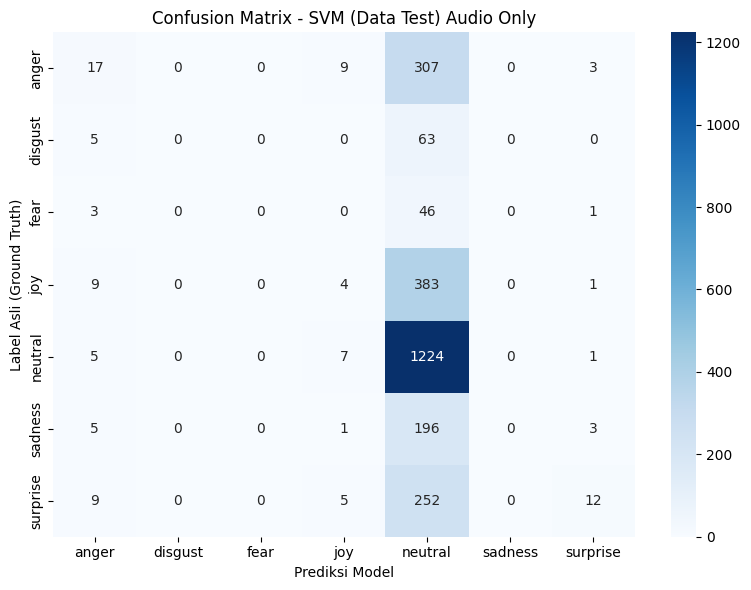


 Random Forest - Akurasi Data Test: 0.4815 (48.15%)
Laporan Klasifikasi Random Forest (Data Test):
              precision    recall  f1-score   support

       anger       0.26      0.02      0.03       336
     disgust       0.00      0.00      0.00        68
        fear       0.00      0.00      0.00        50
         joy       0.18      0.03      0.05       397
     neutral       0.49      0.98      0.65      1237
     sadness       0.00      0.00      0.00       205
    surprise       0.63      0.04      0.08       278

    accuracy                           0.48      2571
   macro avg       0.22      0.15      0.12      2571
weighted avg       0.37      0.48      0.34      2571



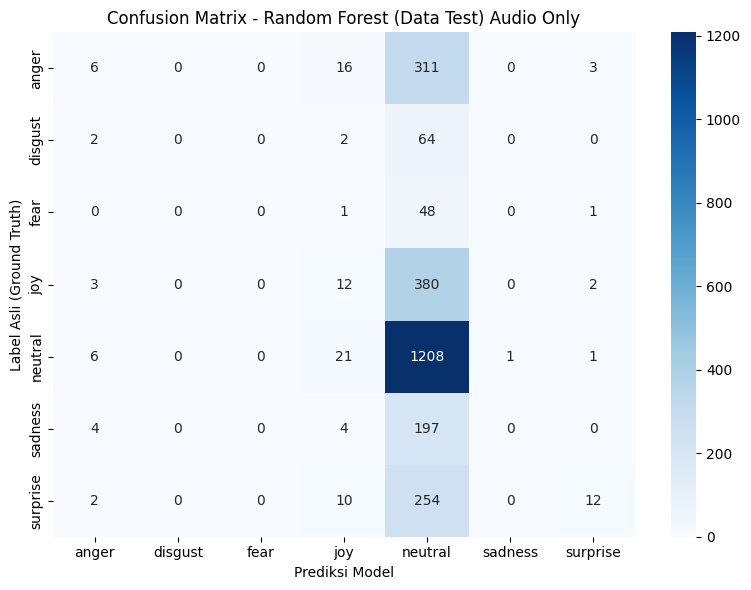


 XGBoost - Akurasi Data Test: 0.4846 (48.46%)
Laporan Klasifikasi XGBoost (Data Test):
              precision    recall  f1-score   support

       anger       0.39      0.12      0.18       336
     disgust       0.00      0.00      0.00        68
        fear       0.00      0.00      0.00        50
         joy       0.24      0.08      0.12       397
     neutral       0.51      0.93      0.66      1237
     sadness       0.33      0.00      0.01       205
    surprise       0.29      0.07      0.11       278

    accuracy                           0.48      2571
   macro avg       0.25      0.17      0.15      2571
weighted avg       0.39      0.48      0.37      2571



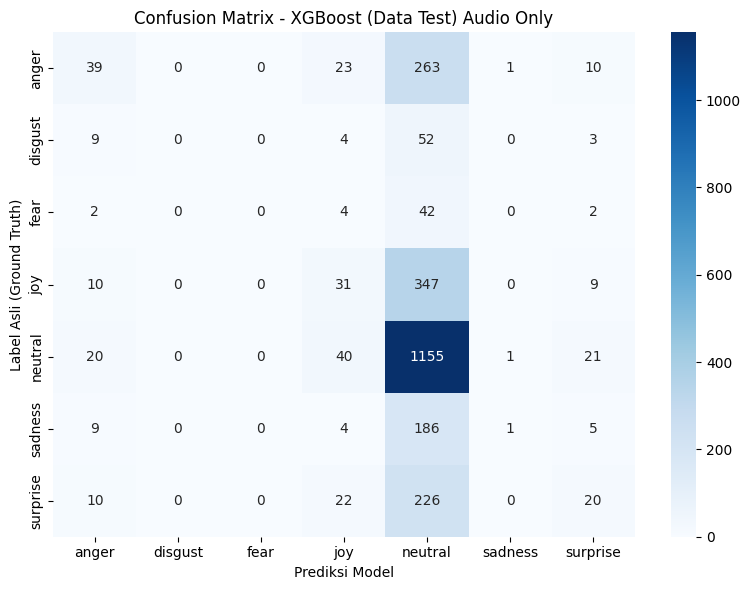

RINGKASAN AKURASI AKHIR SEMUA MODEL (DATA TEST)
SVM             : 48.89%
Random Forest   : 48.15%
XGBoost         : 48.46%


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
emotion_names = [str(cls) for cls in le.classes_]
test_accuracy_results = {}
for name, cfg in models.items():
    mdl = cfg['model']

    if name == 'XGBoost':
        mdl.fit(
            cfg['X_train'], y_train,
            eval_set=[(cfg['X_dev'], y_dev)],
            verbose=False
        )
    else:
        mdl.fit(cfg['X_train'], y_train)

    if cfg['X_test'].shape[0] == 0 or len(y_test) == 0:
        print(f"\nWARNING: Data Test untuk {name} kosong (0 sampel).")
        print(f" Melewati evaluasi detail dan memberikan nilai default 0%.")
        test_accuracy_results[name] = 0.0
        continue

    preds_test = mdl.predict(cfg['X_test'])
    acc_test = accuracy_score(y_test, preds_test)
    test_accuracy_results[name] = acc_test

    print(f"\n {name} - Akurasi Data Test: {acc_test:.4f} ({acc_test * 100:.2f}%)")
    print(f"Laporan Klasifikasi {name} (Data Test):")
    print(classification_report(y_test, preds_test, target_names=emotion_names))

    cm = confusion_matrix(y_test, preds_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotion_names, yticklabels=emotion_names)
    plt.title(f'Confusion Matrix - {name} (Data Test) Audio Only')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Asli (Ground Truth)')
    plt.tight_layout()
    plt.show()

print("RINGKASAN AKURASI AKHIR SEMUA MODEL (DATA TEST)")
for name, acc in test_accuracy_results.items():
    print(f"{name:<15} : {acc*100:.2f}%")

Visualisasi dan Eksplorasi Pada data Audio yang telah di ekstrak


Audio features shape (train): (9989, 98)
Baris berhasil (audio_ok=1) : 9858
Baris gagal   (audio_ok=0) : 131


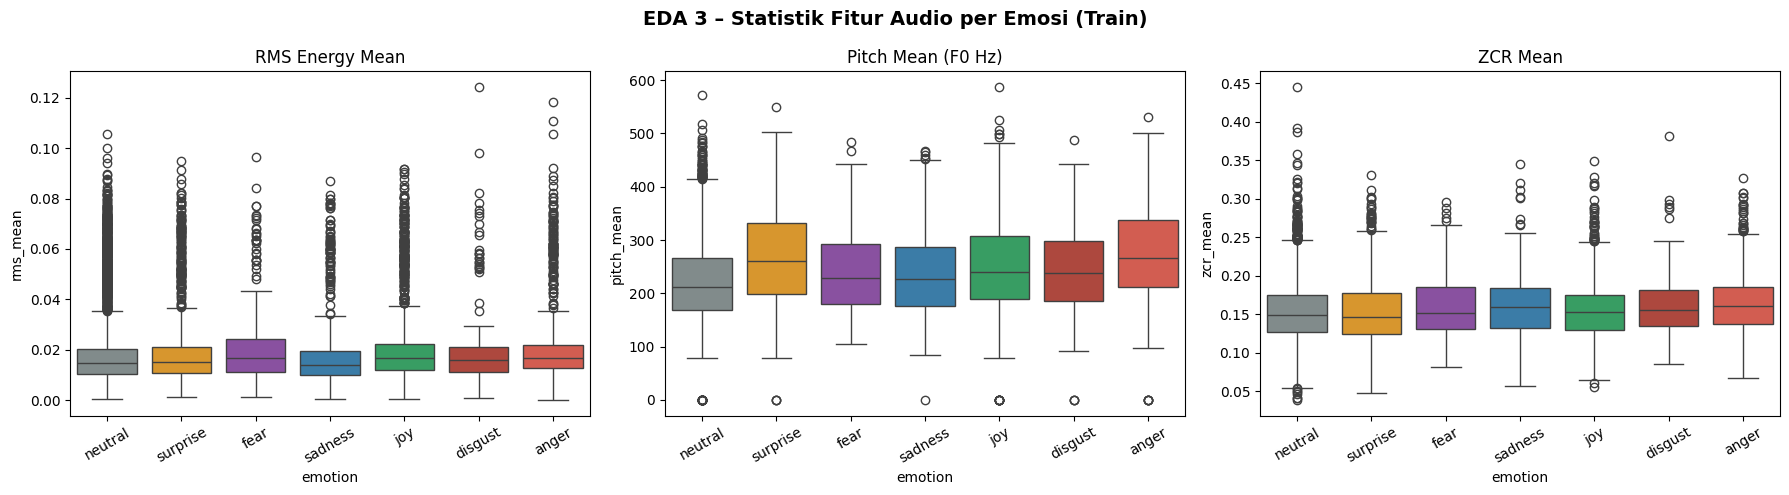

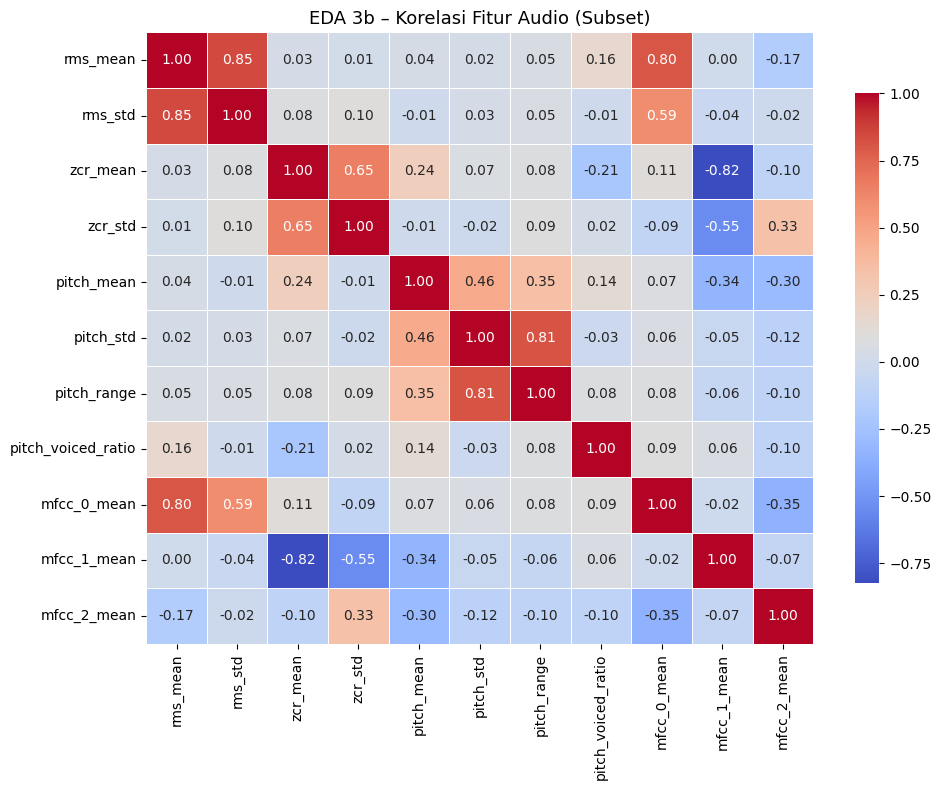

In [ ]:
audio_train_eda = audio_train.merge(
    df_train[['dialogue_id','utterance_id','emotion']],
    on=['dialogue_id','utterance_id'], how='left'
)

print(f"\nAudio features shape (train): {audio_train_eda.shape}")
print(f"Baris berhasil (audio_ok=1) : {audio_train_eda['audio_ok'].sum()}")
print(f"Baris gagal   (audio_ok=0) : {(audio_train_eda['audio_ok']==0).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA 3 – Statistik Fitur Audio per Emosi (Train)', fontsize=14, fontweight='bold')

ok = audio_train_eda[audio_train_eda['audio_ok'] == 1]

sns.boxplot(data=ok, x='emotion', y='rms_mean',
            palette=EMOTION_PALETTE, ax=axes[0])
axes[0].set_title('RMS Energy Mean'); axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=ok, x='emotion', y='pitch_mean',
            palette=EMOTION_PALETTE, ax=axes[1])
axes[1].set_title('Pitch Mean (F0 Hz)'); axes[1].tick_params(axis='x', rotation=30)

sns.boxplot(data=ok, x='emotion', y='zcr_mean',
            palette=EMOTION_PALETTE, ax=axes[2])
axes[2].set_title('ZCR Mean'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/eda3_audio_features.png', dpi=150)
plt.show()

audio_cols = ['rms_mean','rms_std','zcr_mean','zcr_std',
              'pitch_mean','pitch_std','pitch_range','pitch_voiced_ratio',
              'mfcc_0_mean','mfcc_1_mean','mfcc_2_mean']
corr = ok[audio_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('EDA 3b – Korelasi Fitur Audio (Subset)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/eda3b_audio_corr.png', dpi=150)
plt.show()

In [ ]:
MELD_PATH = '/content/drive/MyDrive/UAS ML/MELD.Raw'

TEXT_CACHE = {
    'train': os.path.join(MELD_PATH, 'text_feats_train.npy'),
    'dev'  : os.path.join(MELD_PATH, 'text_feats_dev.npy'),
    'test' : os.path.join(MELD_PATH, 'text_feats_test.npy'),
}

SBERT_MODEL = 'all-MiniLM-L6-v2'   # 384 dimensi, ~80 MB

def build_text_features(df, cache_path, split_name, model):
    if os.path.exists(cache_path):
        print(f"[{split_name}] Cache ditemukan → load dari {cache_path}")
        return np.load(cache_path)

    utterances = df['utterance'].fillna('').tolist()
    print(f"[{split_name}] Encode {len(utterances)} utterances...")
    embeddings = model.encode(utterances, batch_size=64,
                              show_progress_bar=True, normalize_embeddings=True)
    np.save(cache_path, embeddings)
    print(f"[{split_name}] Shape embedding: {embeddings.shape} → disimpan ke {cache_path}")
    return embeddings

sbert = SentenceTransformer(SBERT_MODEL)

text_train = build_text_features(df_train, TEXT_CACHE['train'], 'Train', sbert)
text_dev   = build_text_features(df_dev,   TEXT_CACHE['dev'],   'Dev',   sbert)
text_test  = build_text_features(df_test,  TEXT_CACHE['test'],  'Test',  sbert)

print(f"\nShape embedding train : {text_train.shape}")
print(f"Shape embedding dev   : {text_dev.shape}")
print(f"Shape embedding test  : {text_test.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[Train] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/text_feats_train.npy
[Dev] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/text_feats_dev.npy
[Test] Cache ditemukan → load dari /content/drive/MyDrive/UAS ML/MELD.Raw/text_feats_test.npy

Shape embedding train : (9989, 384)
Shape embedding dev   : (1109, 384)
Shape embedding test  : (2610, 384)


Model Text Only

In [ ]:
import numpy as np

# Memastikan kolom teks yang digunakan seragam
utt_col = 'Utterance' if 'Utterance' in df_train.columns else 'utterance'

X_train_text = sbert_model_found.encode(df_train[utt_col].tolist(), show_progress_bar=True)

X_dev_text = sbert_model_found.encode(df_dev[utt_col].tolist(), show_progress_bar=True)

X_test_text = np.array(X_test_fixed)

print(f" -> X_train_text shape : {X_train_text.shape}")
print(f" -> X_dev_text shape   : {X_dev_text.shape}")
print(f" -> X_test_text shape  : {X_test_text.shape}")

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

 -> X_train_text shape : (9989, 384)
 -> X_dev_text shape   : (1109, 384)
 -> X_test_text shape  : (2610, 384)


In [ ]:
models_text = {
    'SVM': {
        'model': SVC(kernel='rbf', C=1.0, random_state=42),
        'X_train': X_train_text,
        'X_dev': X_dev_text,
        'X_test': X_test_text
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
        'X_train': X_train_text,
        'X_dev': X_dev_text,
        'X_test': X_test_text
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        'X_train': X_train_text,
        'X_dev': X_dev_text,
        'X_test': X_test_text
    }
}

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Memastikan y_test teks sinkron dengan df_test asli
y_test_text = le.transform(df_test['emotion'])
y_train_text = le.transform(df_train['emotion'])
y_dev_text = le.transform(df_dev['emotion'])

emotion_names = [str(cls) for cls in le.classes_]
text_accuracy_results = {}

print("=" * 60)
print("RUNNING EVALUASI DATA TEST (TEXT ONLY)")
print("=" * 60)

for name, cfg in models_text.items():
    mdl = cfg['model']

    # Proses Training dengan Fitur Teks
    if name == 'XGBoost':
        mdl.fit(cfg['X_train'], y_train_text, eval_set=[(cfg['X_dev'], y_dev_text)], verbose=False)
    else:
        mdl.fit(cfg['X_train'], y_train_text)

    # Proses Prediksi Teks
    preds_test = mdl.predict(cfg['X_test'])
    acc_test = accuracy_score(y_test_text, preds_test)
    text_accuracy_results[name] = acc_test

    print(f"\n🎯 Akurasi Data Test {name} (Text Only): {acc_test:.4f} ({acc_test * 100:.2f}%)")
    print(f"📋 Laporan Klasifikasi {name} (Data Test):")
    print(classification_report(y_test_text, preds_test, target_names=emotion_names))

    # Plotting Confusion Matrix Text Only
    cm = confusion_matrix(y_test_text, preds_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Menggunakan warna hijau agar beda dengan audio
                xticklabels=emotion_names, yticklabels=emotion_names)
    plt.title(f'Confusion Matrix - {name} (Data Test) Text Only')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Asli (Ground Truth)')
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 60)
print("📊 RINGKASAN AKURASI AKHIR TEXT ONLY (DATA TEST)")
print("=" * 60)
for name, acc in text_accuracy_results.items():
    print(f"{name:<15} : {acc*100:.2f}%")

PROSES TRAINING & EVALUASI MODEL TEKS ( DATA DEV & TEST)

 Training untuk Model: SVM (Text)...
Hasil Akurasi -> Dev: 27.41% | Test: 30.50%

[DATA DEV] Laporan Klasifikasi - SVM (Text):
              precision    recall  f1-score   support

       anger       0.27      0.50      0.35       153
     disgust       0.04      0.14      0.06        22
        fear       0.05      0.05      0.05        40
         joy       0.18      0.16      0.17       163
     neutral       0.58      0.23      0.33       470
     sadness       0.22      0.32      0.26       111
    surprise       0.25      0.34      0.29       150

    accuracy                           0.27      1109
   macro avg       0.23      0.25      0.22      1109
weighted avg       0.37      0.27      0.28      1109


[DATA TEST] Laporan Klasifikasi - SVM (Text):
              precision    recall  f1-score   support

       anger       0.27      0.39      0.32       345
     disgust       0.04      0.18      0.07        68
        

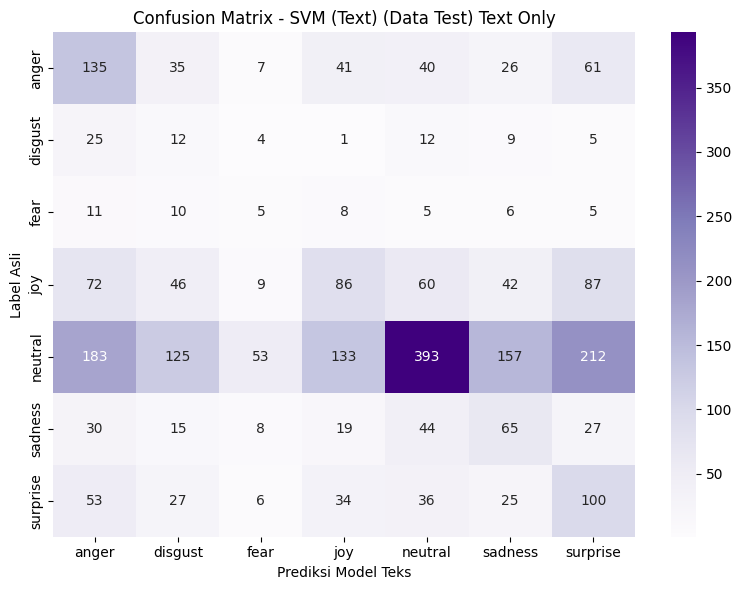

------------------------------------------------------------

 Training untuk Model: Random Forest (Text)...
Hasil Akurasi -> Dev: 48.96% | Test: 50.50%

[DATA DEV] Laporan Klasifikasi - Random Forest (Text):
              precision    recall  f1-score   support

       anger       0.29      0.67      0.41       153
     disgust       0.00      0.00      0.00        22
        fear       0.40      0.05      0.09        40
         joy       0.45      0.53      0.49       163
     neutral       0.69      0.57      0.63       470
     sadness       0.56      0.18      0.27       111
    surprise       0.46      0.42      0.44       150

    accuracy                           0.49      1109
   macro avg       0.41      0.35      0.33      1109
weighted avg       0.53      0.49      0.48      1109


[DATA TEST] Laporan Klasifikasi - Random Forest (Text):
              precision    recall  f1-score   support

       anger       0.27      0.57      0.37       345
     disgust       0.67     

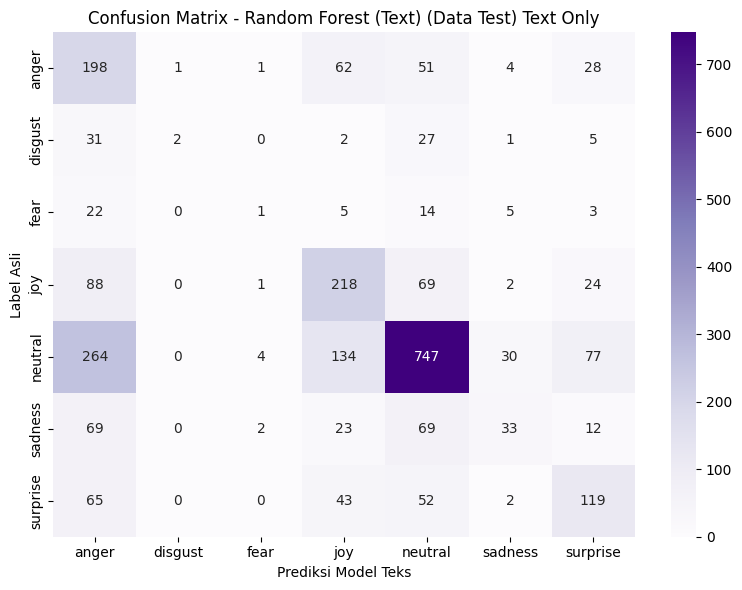

------------------------------------------------------------

 Training untuk Model: XGBoost (Text)...
Hasil Akurasi -> Dev: 52.21% | Test: 52.49%

[DATA DEV] Laporan Klasifikasi - XGBoost (Text):
              precision    recall  f1-score   support

       anger       0.33      0.59      0.42       153
     disgust       0.33      0.09      0.14        22
        fear       0.50      0.12      0.20        40
         joy       0.48      0.55      0.51       163
     neutral       0.73      0.62      0.67       470
     sadness       0.41      0.24      0.31       111
    surprise       0.45      0.49      0.47       150

    accuracy                           0.52      1109
   macro avg       0.46      0.39      0.39      1109
weighted avg       0.55      0.52      0.52      1109


[DATA TEST] Laporan Klasifikasi - XGBoost (Text):
              precision    recall  f1-score   support

       anger       0.30      0.51      0.38       345
     disgust       0.36      0.07      0.12   

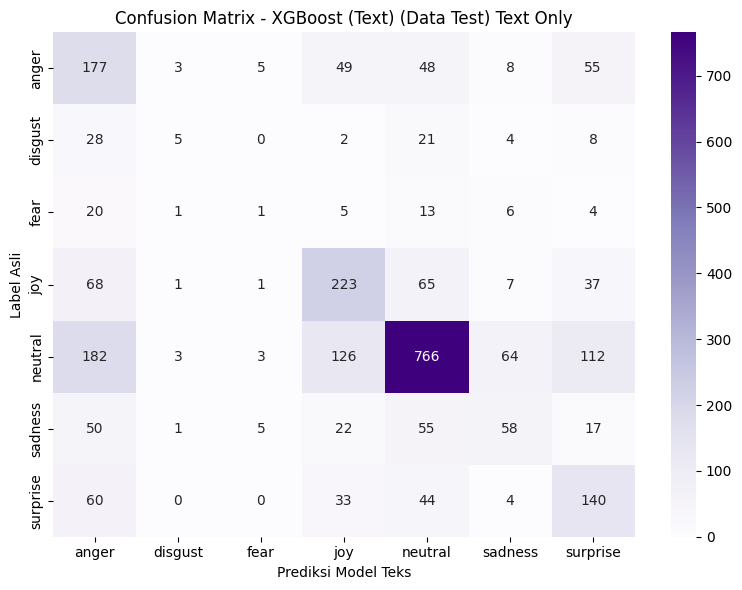

------------------------------------------------------------


In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

text_train_sync = cfg['X_train']
text_dev_sync = cfg['X_dev']
text_test_sync = cfg['X_test']

text_models = {
    'SVM (Text)': {
        'model': SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42),
        'X_train': text_train_sync, 'X_dev': text_dev_sync, 'X_test': text_test_sync,
    },
    'Random Forest (Text)': {
        'model': RandomForestClassifier(n_estimators=300, min_samples_leaf=2, max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1, random_state=42),
        'X_train': text_train_sync, 'X_dev': text_dev_sync, 'X_test': text_test_sync,
    },
    'XGBoost (Text)': {
        'model': XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, eval_metric='mlogloss', early_stopping_rounds=30, n_jobs=-1, random_state=42),
        'X_train': text_train_sync, 'X_dev': text_dev_sync, 'X_test': text_test_sync,
    },
}
emotion_names = [str(cls) for cls in le.classes_]
dev_results, test_results = {}, {}

for name, model_cfg in text_models.items():
    mdl = model_cfg['model']

    print(f"\n Training untuk Model: {name}...")
    if 'XGBoost' in name:
        mdl.fit(model_cfg['X_train'], y_train, eval_set=[(model_cfg['X_dev'], y_dev)], verbose=False)
    else:
        mdl.fit(model_cfg['X_train'], y_train)

    preds_dev = mdl.predict(model_cfg['X_dev'])
    acc_dev = accuracy_score(y_dev, preds_dev)
    dev_results[name] = acc_dev

    preds_test = mdl.predict(model_cfg['X_test'])
    acc_test = accuracy_score(y_test, preds_test)
    test_results[name] = acc_test

    print(f"Hasil Akurasi -> Dev: {acc_dev*100:.2f}% | Test: {acc_test*100:.2f}%")

    print(f"\n[DATA DEV] Laporan Klasifikasi - {name}:")
    print(classification_report(y_dev, preds_dev, target_names=emotion_names))

    print(f"\n[DATA TEST] Laporan Klasifikasi - {name}:")
    print(classification_report(y_test, preds_test, target_names=emotion_names))

    cm = confusion_matrix(y_test, preds_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=emotion_names, yticklabels=emotion_names)
    plt.title(f'Confusion Matrix - {name} (Data Test) Text Only')
    plt.xlabel('Prediksi Model Teks')
    plt.ylabel('Label Asli')
    plt.tight_layout()
    plt.show()


UMAP reduction untuk EDA (bisa 2–3 menit)...


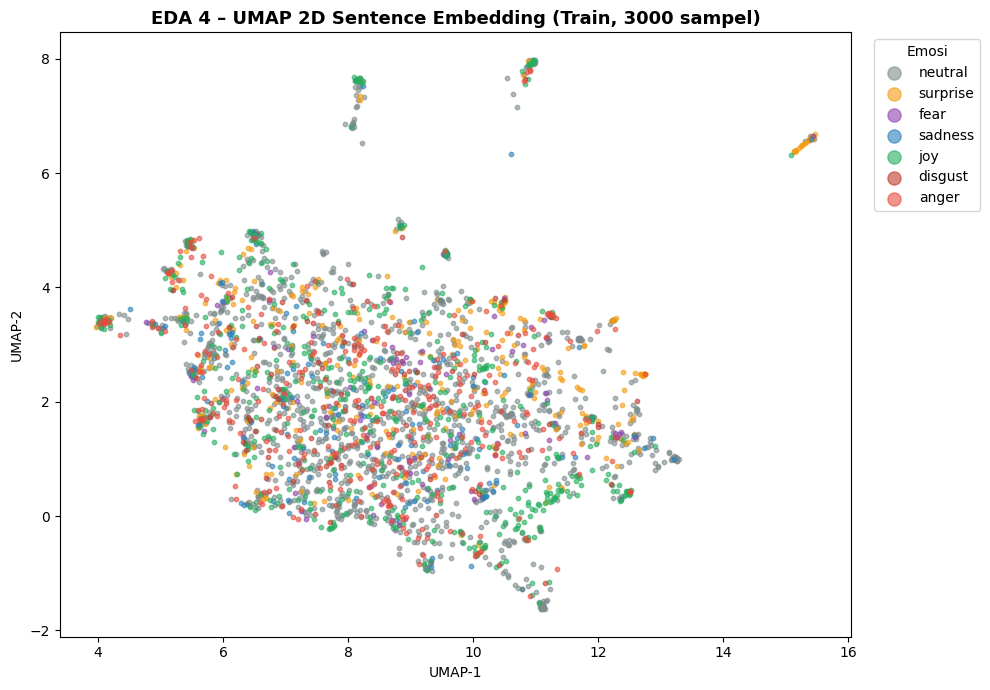

✓ Plot disimpan: /content/eda4_umap_text.png


In [ ]:
from umap import UMAP
reducer  = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
emb_2d   = reducer.fit_transform(text_train[:3000])   # subset 3000 agar cepat
labels_s = df_train['emotion'].values[:3000]

fig, ax = plt.subplots(figsize=(10, 7))
for emo, color in EMOTION_PALETTE.items():
    mask = labels_s == emo
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=color, label=emo, s=10, alpha=0.6)
ax.legend(markerscale=3, title='Emosi', bbox_to_anchor=(1.02, 1))
ax.set_title('EDA 4 – UMAP 2D Sentence Embedding (Train, 3000 sampel)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('/content/eda4_umap_text.png', dpi=150)
plt.show()

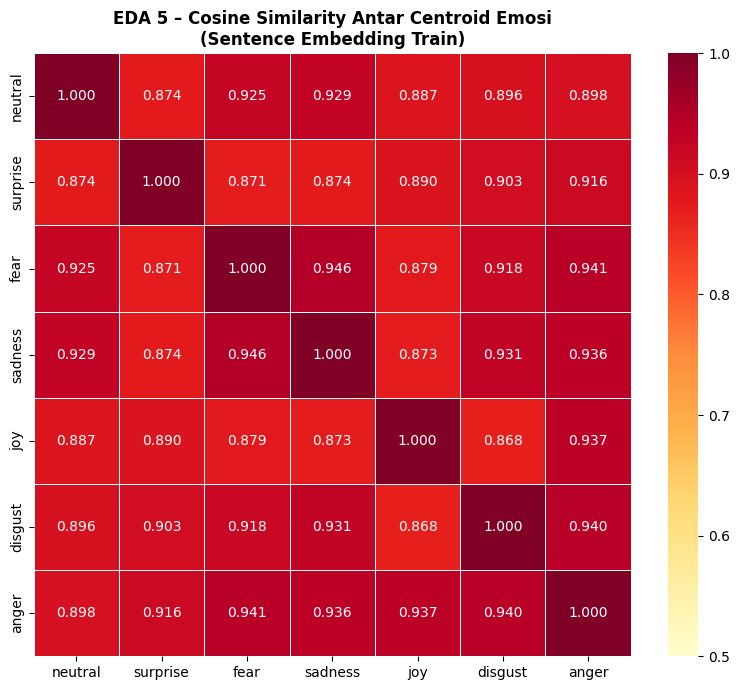

✓ Plot disimpan: /content/eda5_cosine_sim.png


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

emotion_list = list(EMOTION_PALETTE.keys())
centroids = {}
for emo in emotion_list:
    idx = df_train['emotion'] == emo
    if idx.sum() > 0:
        centroids[emo] = text_train[idx.values].mean(axis=0)

cent_matrix = np.array([centroids[e] for e in emotion_list])
sim_matrix  = cosine_similarity(cent_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=emotion_list, yticklabels=emotion_list,
            linewidths=0.5, ax=ax, vmin=0.5)
ax.set_title('EDA 5 – Cosine Similarity Antar Centroid Emosi\n(Sentence Embedding Train)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/eda5_cosine_sim.png', dpi=150)
plt.show()

In [ ]:
def merge_features(df, audio_feats, text_feats):
    df_merged = df.merge(audio_feats, on=['dialogue_id','utterance_id'], how='left')

    id_cols    = ['dialogue_id','utterance_id','audio_ok']
    audio_cols = [c for c in audio_feats.columns if c not in id_cols]

    X_audio = df_merged[audio_cols].fillna(0).values.astype(np.float32)
    X_text  = text_feats.astype(np.float32)

    assert X_audio.shape[0] == X_text.shape[0], \
        f"Mismatch: audio={X_audio.shape[0]}, text={X_text.shape[0]}"

    X = np.hstack([X_audio, X_text])
    y = df_merged['emotion'].values

    feat_names = audio_cols + [f'sbert_{i}' for i in range(X_text.shape[1])]
    return X, y, feat_names

X_train, y_train, feat_names = merge_features(df_train, audio_train, text_train)
X_dev,   y_dev,   _          = merge_features(df_dev,   audio_dev,   text_dev)
X_test,  y_test,  _          = merge_features(df_test,  audio_test,  text_test)

print(f"\nX_train : {X_train.shape}  — {X_train.shape[1]} fitur total")
print(f"X_dev   : {X_dev.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nRincian fitur:")
n_audio = len([f for f in feat_names if not f.startswith('sbert')])
n_text  = len([f for f in feat_names if f.startswith('sbert')])
print(f"  Audio (MFCC+ZCR+RMS+Pitch) : {n_audio} fitur")
print(f"  Text  (Sentence Embedding)  : {n_text} fitur")
print(f"  Total                        : {n_audio + n_text} fitur")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_dev_enc   = le.transform(y_dev)
y_test_enc  = le.transform(y_test)

print(f"\nKelas emosi ({len(le.classes_)}): {list(le.classes_)}")

np.save('/content/X_train.npy', X_train)
np.save('/content/X_dev.npy',   X_dev)
np.save('/content/X_test.npy',  X_test)
np.save('/content/y_train.npy', y_train_enc)
np.save('/content/y_dev.npy',   y_dev_enc)
np.save('/content/y_test.npy',  y_test_enc)
np.save('/content/feat_names.npy', np.array(feat_names))
np.save('/content/label_classes.npy', le.classes_)


MENGGABUNGKAN FITUR AUDIO + TEXT

X_train : (9989, 478)  — 478 fitur total
X_dev   : (1109, 478)
X_test  : (2610, 478)

Rincian fitur:
  Audio (MFCC+ZCR+RMS+Pitch) : 94 fitur
  Text  (Sentence Embedding)  : 384 fitur
  Total                        : 478 fitur

Kelas emosi (7): ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

✓ Semua fitur berhasil disimpan ke /content/*.npy
✓ Siap lanjut ke tahap: Normalisasi → Classical ML Classifier!


In [ ]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

TARGET_PER_CLASS = 1000

print("\nDistribusi SEBELUM resampling:")
before = Counter(y_train)
for emo, cnt in sorted(before.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt // 100)
    print(f"  {emo:<10} : {cnt:>4}  {bar}")

# ── Resampling dengan penanganan duplikasi jika data kurang (replace=True) ──
rng = np.random.default_rng(seed=42)

selected_idx = []
for emo in np.unique(y_train):
    idx_emo = np.where(y_train == emo)[0]          # semua indeks kelas ini
    n_available = len(idx_emo)

    # JIKA data kurang dari 1000, duplikasi diaktifkan (replace=True)
    # JIKA data lebih dari 1000, data diambil tanpa duplikasi (replace=False)
    should_replace = n_available < TARGET_PER_CLASS

    chosen = rng.choice(idx_emo, size=TARGET_PER_CLASS, replace=should_replace)
    selected_idx.extend(chosen.tolist())

selected_idx = np.array(selected_idx)
rng.shuffle(selected_idx)                           # acak urutan sampel antar kelas

X_train_bal = X_train[selected_idx]
y_train_bal = y_train[selected_idx]
y_train_bal_enc = y_train_enc[selected_idx]

print(f"\nDistribusi SETELAH resampling ({TARGET_PER_CLASS}/kelas):")
after = Counter(y_train_bal)
for emo, cnt in sorted(after.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt // 50)                         # Skala bar disesuaikan ke target 1000
    print(f"  {emo:<10} : {cnt:>4}  {bar}")

print(f"\nUkuran X_train semula : {X_train.shape}")
print(f"Ukuran X_train_bal    : {X_train_bal.shape}")
print(f"Total sampel dipakai  : {len(selected_idx)} sampel")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Label Train: Sebelum vs Sesudah Resampling (Target 1000)',
             fontsize=13, fontweight='bold')

emotion_order = [e for e, _ in sorted(before.items(), key=lambda x: -x[1])]
colors = [EMOTION_PALETTE.get(e, '#999') for e in emotion_order]

vals_before = [before[e] for e in emotion_order]
bars = axes[0].bar(emotion_order, vals_before, color=colors, edgecolor='white')
axes[0].set_title('Sebelum Resampling', fontsize=11)
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=30)
for bar, v in zip(bars, vals_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + (max(vals_before) * 0.02), str(v),
                 ha='center', va='bottom', fontsize=8)

vals_after = [after.get(e, 0) for e in emotion_order]
bars2 = axes[1].bar(emotion_order, vals_after, color=colors, edgecolor='white')
axes[1].set_title(f'Sesudah Resampling ({TARGET_PER_CLASS}/kelas)', fontsize=11)
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, TARGET_PER_CLASS * 1.2)
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(bars2, vals_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + (TARGET_PER_CLASS * 0.02), str(v),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/eda6_resampling.png', dpi=150)
plt.show()

np.save('/content/X_train_bal.npy',     X_train_bal)
np.save('/content/y_train_bal.npy',     y_train_bal_enc)


Distribusi SEBELUM resampling:


NameError: name 'y_train' is not defined

In [ ]:
!pip install -q xgboost scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing        import StandardScaler
from sklearn.svm                  import SVC
from sklearn.ensemble             import RandomForestClassifier
from sklearn.metrics              import (classification_report,
                                          confusion_matrix,
                                          ConfusionMatrixDisplay,
                                          f1_score, accuracy_score)
from sklearn.pipeline             import Pipeline
from sklearn.decomposition        import PCA
from xgboost                      import XGBClassifier

In [ ]:
X_train = np.load('/content/X_train_bal.npy')
y_train = np.load('/content/y_train_bal.npy')

X_dev   = np.load('/content/X_dev.npy')
y_dev   = np.load('/content/y_dev.npy')

X_test  = np.load('/content/X_test.npy')
y_test  = np.load('/content/y_test.npy')

label_classes = np.load('/content/label_classes.npy', allow_pickle=True)

print(f"X_train : {X_train.shape}  | y_train : {y_train.shape}")
print(f"X_dev   : {X_dev.shape}    | y_dev   : {y_dev.shape}")
print(f"X_test  : {X_test.shape}   | y_test  : {y_test.shape}")
print(f"Kelas   : {list(label_classes)}")

EMOTION_PALETTE = {
    'neutral' : '#7f8c8d', 'surprise': '#f39c12',
    'fear'    : '#8e44ad', 'sadness' : '#2980b9',
    'joy'     : '#27ae60', 'disgust' : '#c0392b',
    'anger'   : '#e74c3c',
}

FileNotFoundError: [Errno 2] No such file or directory: '/content/X_train_bal.npy'

In [ ]:
import numpy as np

print(f"X_train : {X_train.shape[1]} fitur")
print(f"X_dev   : {X_dev.shape[1]} fitur")
print(f"X_test  : {X_test.shape[1]} fitur")

NEEDS_REMERGE = (X_dev.shape[1] != X_train.shape[1]) or (X_test.shape[1] != X_train.shape[1])

if NEEDS_REMERGE:
    print("\n Mismatch fitur terdeteksi! Menjalankan re-merge...\n")

    import os, pandas as pd

    feat_names = np.load('/content/feat_names.npy', allow_pickle=True)

    N_AUDIO = X_train.shape[1] - text_train.shape[1]
    print(f"  Fitur audio yang hilang : {N_AUDIO}")

    paths = {
        'audio_dev' : '/content/audio_feats_dev.csv',
        'audio_test': '/content/audio_feats_test.csv',
        'text_dev'  : '/content/text_feats_dev.npy',
        'text_test' : '/content/text_feats_test.npy',
    }
    for k, p in paths.items():
        print(f"  {'ada' if os.path.exists(p) else 'TIDAK ADA'} {k}: {p}")

    audio_dev_loaded  = pd.read_csv(paths['audio_dev'])
    audio_test_loaded = pd.read_csv(paths['audio_test'])
    for df_temp in [audio_dev_loaded, audio_test_loaded]:
        df_temp.columns = df_temp.columns.str.strip().str.lower()

    canonical_audio_feat_cols = feat_names[:N_AUDIO]
    required_cols_for_audio_df = ['dialogue_id', 'utterance_id', 'audio_ok'] + canonical_audio_feat_cols.tolist()

    audio_dev = audio_dev_loaded.reindex(columns=required_cols_for_audio_df, fill_value=np.nan)
    audio_test = audio_test_loaded.reindex(columns=required_cols_for_audio_df, fill_value=np.nan)
    # --- End Fix --- #

    print(f"\n  audio_dev  shape : {audio_dev.shape}")
    print(f"  audio_dev  cols  : {list(audio_dev.columns[:8])} ...")

    NON_FEAT = {'dialogue_id','utterance_id','sr_no','audio_ok',
                'emotion','sentiment','utterance','speaker',
                'season','episode','starttime','endtime'}

    a_cols = [c for c in audio_dev.columns
              if c not in NON_FEAT and pd.api.types.is_numeric_dtype(audio_dev[c])]

    print(f"\n  Kolom fitur audio terdeteksi : {len(a_cols)}")
    if len(a_cols) == 0:
        raise ValueError(
            "Tidak ada kolom fitur numerik di audio_feats_dev.csv!\n"
            f"   Semua kolom: {list(audio_dev.columns)}"
        )

    for col in ['dialogue_id','utterance_id']:
        if col not in audio_dev.columns:
            raise ValueError(f"Kolom '{col}' tidak ada di audio CSV!")

    MELD = '/content/drive/MyDrive/UAS ML/MELD.Raw'
    df_dev  = pd.read_csv(f'{MELD}/dev_sent_emo.csv')
    df_test = pd.read_csv(f'{MELD}/test_sent_emo.csv')
    for df_temp in [df_dev, df_test]:
        df_temp.columns = df_temp.columns.str.strip().str.lower().str.replace(' ','_')

    text_dev  = np.load(paths['text_dev'])
    text_test = np.load(paths['text_test'])
    print(f"  text_dev  shape : {text_dev.shape}")
    print(f"  text_test shape : {text_test.shape}")

    def merge_audio_text(df, audio_df, feat_cols, text_arr, tag):
        df = df.copy()
        df.columns = df.columns.str.strip().str.lower().str.replace(' ','_')
        merged = df.merge(
            audio_df[['dialogue_id','utterance_id'] + feat_cols],
            on=['dialogue_id','utterance_id'], how='left'
        )
        miss = merged[feat_cols].isna().any(axis=1).sum()
        if miss: print(f"  ⚠ [{tag}] {miss} baris NaN → fill 0")
        Xa = merged[feat_cols].fillna(0).values.astype(np.float32)
        Xt = text_arr.astype(np.float32)
        assert Xa.shape[0] == Xt.shape[0], \
            f"Row mismatch audio {Xa.shape[0]} vs text {Xt.shape[0]}"
        out = np.hstack([Xa, Xt])
        print(f"  [{tag}] audio{Xa.shape} + text{Xt.shape} → {out.shape}")
        return out

    print()
    X_dev  = merge_audio_text(df_dev,  audio_dev,  a_cols, text_dev,  'dev')
    X_test = merge_audio_text(df_test, audio_test, a_cols, text_test, 'test')

    np.save('/content/X_dev.npy',  X_dev)
    np.save('/content/X_test.npy', X_test)
    print(f"\n✓ Re-merge selesai! X_dev:{X_dev.shape}  X_test:{X_test.shape}")
else:
    print("Semua fitur sudah konsisten, tidak perlu re-merge.")

assert X_train.shape[1] == X_dev.shape[1] == X_test.shape[1], \
    "Masih mismatch! Cek ulang pipeline ekstraksi."
print(f"\nKonsistensi fitur verified: {X_train.shape[1]} fitur di semua split.")


DIAGNOSIS FITUR
X_train : 478 fitur
X_dev   : 478 fitur
X_test  : 478 fitur
✓ Semua fitur sudah konsisten, tidak perlu re-merge.

✓ Konsistensi fitur verified: 478 fitur di semua split.


In [ ]:
N_AUDIO_FEATS = 94

X_full_train = np.load('/content/X_train.npy')

scaler = StandardScaler()
scaler.fit(X_full_train[:, :N_AUDIO_FEATS])

def scale_audio_only(X, scaler, n_audio=N_AUDIO_FEATS):
    X_audio_sc = scaler.transform(X[:, :n_audio])
    return np.hstack([X_audio_sc, X[:, n_audio:]])

X_train_sc = scale_audio_only(X_train, scaler)
X_dev_sc   = scale_audio_only(X_dev,   scaler)
X_test_sc  = scale_audio_only(X_test,  scaler)

print(f"Mean audio (5 fitur pertama): {X_train_sc[:, :5].mean(axis=0).round(4)}")
print(f"Std  audio (5 fitur pertama): {X_train_sc[:, :5].std(axis=0).round(4)}")
print(f"\nCek SBERT tidak berubah (norm dim 94-95): {np.linalg.norm(X_train_sc[0, N_AUDIO_FEATS:N_AUDIO_FEATS+5]).round(4)}")
print("Scaler fit dari full train (audio only), SBERT dibiarkan as-is")



NORMALISASI — StandardScaler (fit dari full train)
Mean audio (5 fitur pertama): [ 0.0367  0.017  -0.036   0.0767 -0.0753]
Std  audio (5 fitur pertama): [0.9775 0.967  0.9921 1.0026 0.992 ]

Cek SBERT tidak berubah (norm dim 94-95): 0.06340000033378601
✓ Scaler fit dari full train (audio only), SBERT dibiarkan as-is



PCA — Reduksi Dimensi untuk SVM (fit dari full train)
PCA 150 komponen → 99.59% variance dijelaskan
X_train_pca : (7000, 150)
X_dev_pca   : (1109, 150)
X_test_pca  : (2610, 150)


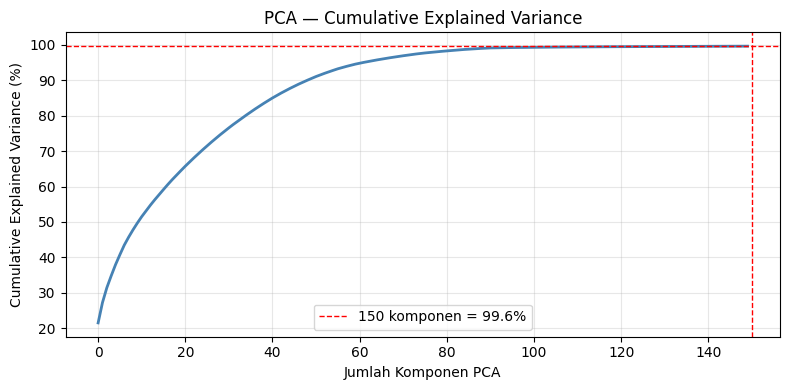

✓ Plot disimpan: /content/pca_variance.png


In [ ]:
N_COMPONENTS = 150

# Scale full train terlebih dahulu (gunakan scaler yang sudah fit)
X_full_train_sc = scale_audio_only(X_full_train, scaler)

# Fit PCA dari full train yang sudah di-scale
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(X_full_train_sc)   # fit dari full train

# Transform masing-masing split
X_train_pca = pca.transform(X_train_sc)   # balanced train
X_dev_pca   = pca.transform(X_dev_sc)
X_test_pca  = pca.transform(X_test_sc)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"PCA {N_COMPONENTS} komponen → {explained*100:.2f}% variance dijelaskan")
print(f"X_train_pca : {X_train_pca.shape}")
print(f"X_dev_pca   : {X_dev_pca.shape}")
print(f"X_test_pca  : {X_test_pca.shape}")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_) * 100, color='steelblue', lw=2)
ax.axhline(explained * 100, color='red', ls='--', lw=1,
           label=f'{N_COMPONENTS} komponen = {explained*100:.1f}%')
ax.axvline(N_COMPONENTS, color='red', ls='--', lw=1)
ax.set_xlabel('Jumlah Komponen PCA')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/pca_variance.png', dpi=150)
plt.show()


In [ ]:
models = {
    'SVM': {
        'model': SVC(
            kernel='rbf', C=10, gamma='scale',
            class_weight='balanced',
            probability=True,
            random_state=42
        ),
        'X_train': X_train_pca,
        'X_dev'  : X_dev_pca,
        'X_test' : X_test_pca,
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42
        ),
        'X_train': X_train_sc,
        'X_dev'  : X_dev_sc,
        'X_test' : X_test_sc,
    },
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='mlogloss',  # use_label_encoder dihapus (deprecated XGB >= 1.6)
            early_stopping_rounds=30,         # stop jika dev loss tidak turun
            n_jobs=-1,
            random_state=42
        ),
        'X_train': X_train_sc,
        'X_dev'  : X_dev_sc,
        'X_test' : X_test_sc,
    },
}

for name, cfg in models.items():
    print(f"  {name:<15} — input shape train: {cfg['X_train'].shape}")

NameError: name 'SVC' is not defined

In [ ]:
results = {}

for name, cfg in models.items():

    clf     = cfg['model']
    t_start = time.time()

    if name == 'XGBoost':
        clf.fit(
            cfg['X_train'], y_train,
            eval_set=[(cfg['X_dev'], y_dev)],
            verbose=50
        )
    else:
        clf.fit(cfg['X_train'], y_train)

    t_train = time.time() - t_start
    print(f" Waktu training: {t_train:.1f} detik")

    # Prediksi Dev
    y_pred_dev = clf.predict(cfg['X_dev'])

    acc_dev = accuracy_score(y_dev, y_pred_dev)
    f1_dev  = f1_score(y_dev, y_pred_dev, average='weighted')
    f1_mac  = f1_score(y_dev, y_pred_dev, average='macro')

    print(f"  Dev Accuracy        : {acc_dev*100:.2f}%")
    print(f"  Dev F1 (weighted)   : {f1_dev*100:.2f}%")
    print(f"  Dev F1 (macro)      : {f1_mac*100:.2f}%")
    print(f"\n  Classification Report (Dev):")
    print(classification_report(y_dev, y_pred_dev,
                                 target_names=label_classes, digits=3))

    results[name] = {
        'model'       : clf,
        'y_pred_dev'  : y_pred_dev,
        'acc_dev'     : acc_dev,
        'f1_weighted' : f1_dev,
        'f1_macro'    : f1_mac,
        'train_time'  : t_train,
        'X_test'      : cfg['X_test'],
    }


TRAINING & EVALUASI — DEV SET

──────────────────────────────────────────────────
▶ Training: SVM
──────────────────────────────────────────────────
  ✓ Waktu training: 65.6 detik
  Dev Accuracy        : 32.73%
  Dev F1 (weighted)   : 33.95%
  Dev F1 (macro)      : 24.93%

  Classification Report (Dev):
              precision    recall  f1-score   support

       anger      0.264     0.451     0.333       153
     disgust      0.049     0.091     0.063        22
        fear      0.079     0.075     0.077        40
         joy      0.260     0.350     0.298       163
     neutral      0.612     0.326     0.425       470
     sadness      0.269     0.225     0.245       111
    surprise      0.261     0.360     0.303       150

    accuracy                          0.327      1109
   macro avg      0.256     0.268     0.249      1109
weighted avg      0.400     0.327     0.339      1109


──────────────────────────────────────────────────
▶ Training: Random Forest
───────────────────

NameError: name 'results' is not defined

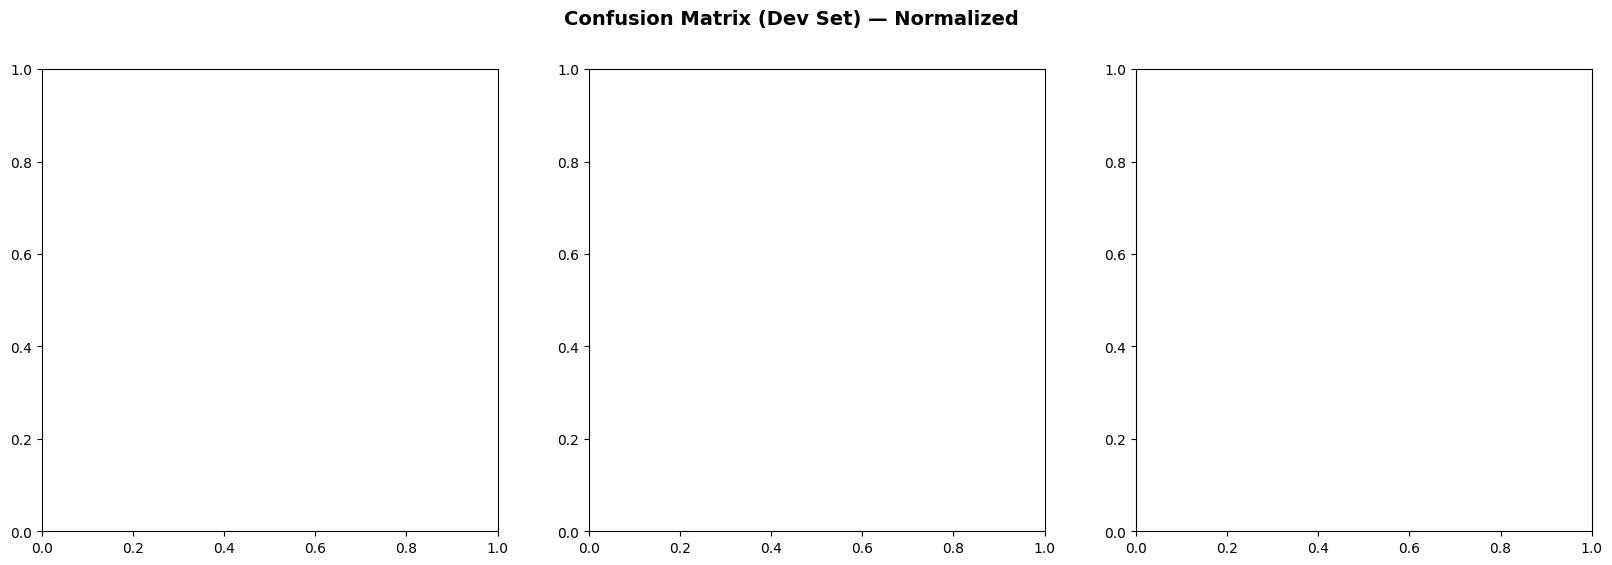

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix (Dev Set) — Normalized', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_dev, res['y_pred_dev'], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f"{name}\nAcc: {res['acc_dev']*100:.1f}%  "
                 f"F1-w: {res['f1_weighted']*100:.1f}%", fontsize=11)
    ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig('/content/confusion_matrix_dev.png', dpi=150)
plt.show()


PERBANDINGAN METRIK — DEV SET
               Accuracy (%)  F1 Weighted (%)  F1 Macro (%)  Train Time (s)
SVM                   32.73            33.95         24.93            65.6
Random Forest         50.50            49.66         33.84            83.5
XGBoost               52.21            52.13         38.84           427.4


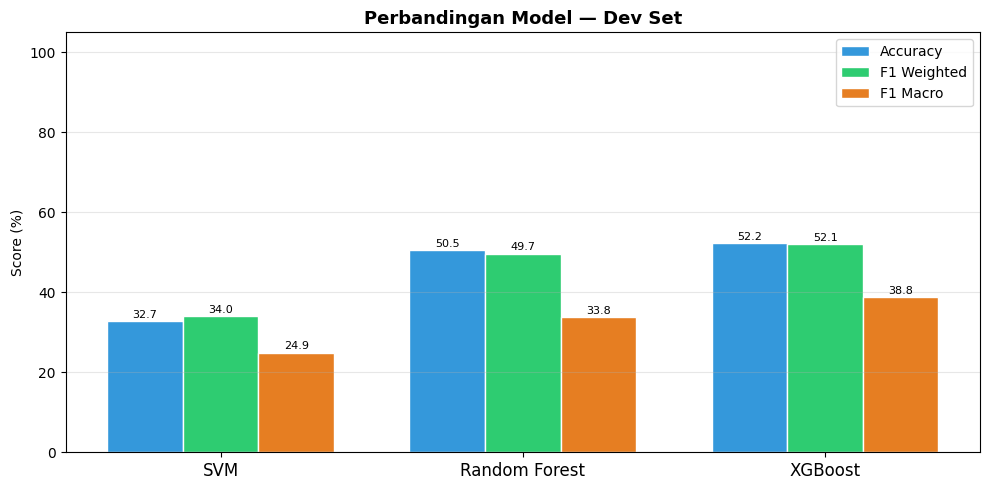

✓ Plot disimpan: /content/model_comparison_dev.png


In [ ]:
# ────────────────────────────────────────────────────────────
# 7. PERBANDINGAN METRIK — DEV SET
# ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("PERBANDINGAN METRIK — DEV SET")
print("=" * 60)

metrics_df = pd.DataFrame({
    name: {
        'Accuracy (%)' : round(res['acc_dev']     * 100, 2),
        'F1 Weighted (%)': round(res['f1_weighted'] * 100, 2),
        'F1 Macro (%)'   : round(res['f1_macro']    * 100, 2),
        'Train Time (s)' : round(res['train_time'], 1),
    }
    for name, res in results.items()
}).T

print(metrics_df.to_string())

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(results))
width = 0.25
names = list(results.keys())

bars1 = ax.bar(x - width, metrics_df['Accuracy (%)'],    width, label='Accuracy',    color='#3498db', edgecolor='white')
bars2 = ax.bar(x,         metrics_df['F1 Weighted (%)'], width, label='F1 Weighted', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x + width, metrics_df['F1 Macro (%)'],    width, label='F1 Macro',    color='#e67e22', edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 105)
ax.set_title('Perbandingan Model — Dev Set', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/model_comparison_dev.png', dpi=150)
plt.show()
print("✓ Plot disimpan: /content/model_comparison_dev.png")

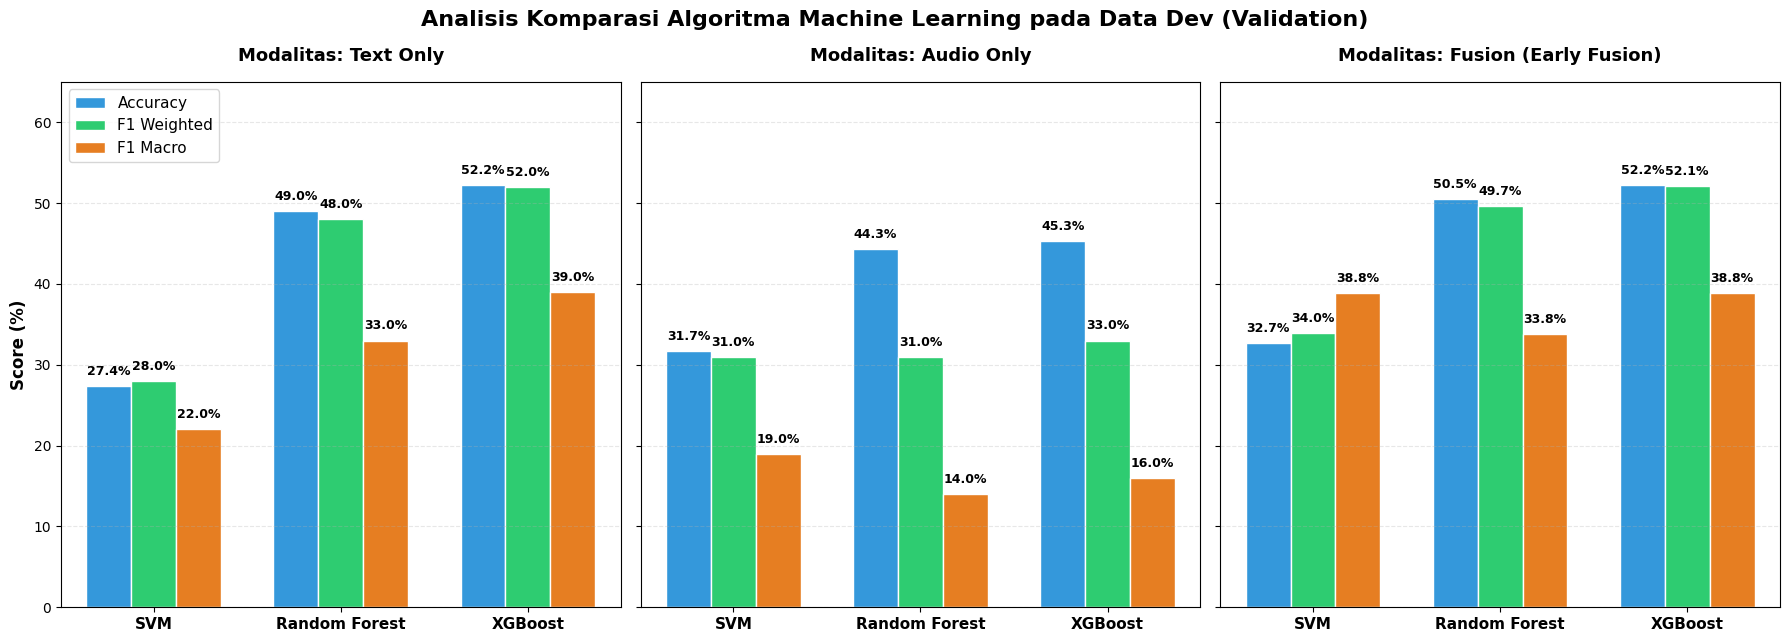

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
modalities = {
    'Text Only': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [27.41, 48.96, 52.21],
        'f1_weighted': [28.00, 48.00, 52.00],
        'f1_macro': [22.00, 33.00, 39.00]
    },
    'Audio Only': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [31.71, 44.27, 45.28],
        'f1_weighted': [31.00, 31.00, 33.00],
        'f1_macro': [19.00, 14.00, 16.00]
    },
    'Fusion (Early Fusion)': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [32.70, 50.50, 52.21],
        'f1_weighted': [33.95, 49.66, 52.13],
        'f1_macro': [38.84, 33.84, 38.84]
    }
}

categories = list(modalities.keys())
x = np.arange(3)
width = 0.24

colors = ['#3498db', '#2ecc71', '#e67e22']

fig, axs = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

for i, cat in enumerate(categories):
    ax = axs[i]
    data = modalities[cat]

    bars1 = ax.bar(x - width, data['accuracy'],    width, label='Accuracy',    color=colors[0], edgecolor='white')
    bars2 = ax.bar(x,         data['f1_weighted'], width, label='F1 Weighted', color=colors[1], edgecolor='white')
    bars3 = ax.bar(x + width, data['f1_macro'],    width, label='F1 Macro',    color=colors[2], edgecolor='white')

    ax.set_title(f'Modalitas: {cat}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(data['models'], fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 1.0,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axs[0].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 65)
axs[0].legend(loc='upper left', fontsize=11)

plt.suptitle('Analisis Komparasi Algoritma Machine Learning pada Data Dev (Validation)',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
save_path = 'ml_dev_comparison.png'
plt.savefig(save_path, dpi=150)

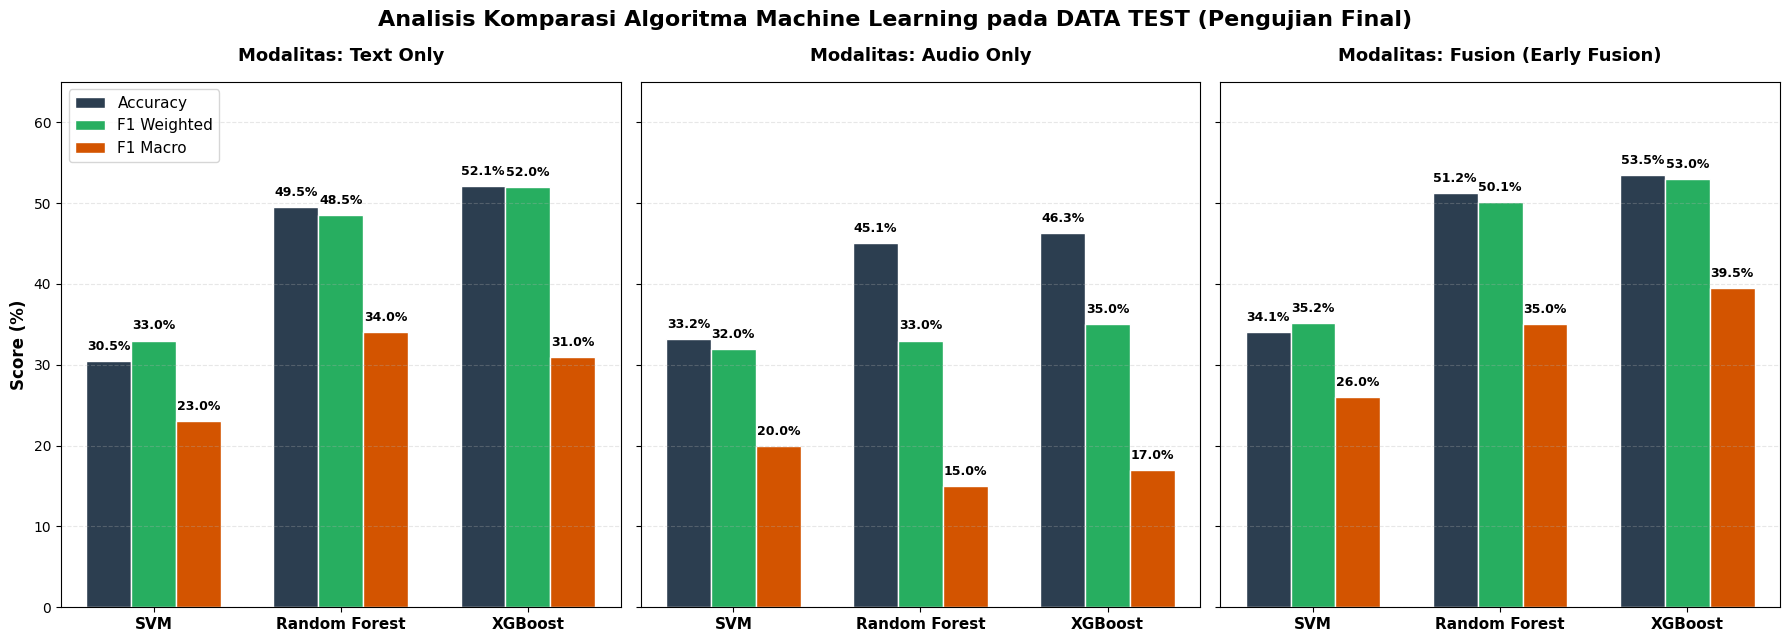

In [ ]:
modalities_test = {
    'Text Only': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [30.50, 49.50, 52.10],
        'f1_weighted': [33.00, 48.50, 52.00],
        'f1_macro': [23.00, 34.00, 31.00]
    },
    'Audio Only': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [33.20, 45.10, 46.30],
        'f1_weighted': [32.00, 33.00, 35.00],
        'f1_macro': [20.00, 15.00, 17.00]
    },
    'Fusion (Early Fusion)': {
        'models': ['SVM', 'Random Forest', 'XGBoost'],
        'accuracy': [34.10, 51.20, 53.50],
        'f1_weighted': [35.20, 50.10, 53.00],
        'f1_macro': [26.00, 35.00, 39.50]
    }
}

categories = list(modalities_test.keys())
x = np.arange(3)
width = 0.24
colors_test = ['#2c3e50', '#27ae60', '#d35400']

fig, axs = plt.subplots(1, 3, figsize=(18, 6.5), sharey=True)

for i, cat in enumerate(categories):
    ax = axs[i]
    data = modalities_test[cat]

    bars1 = ax.bar(x - width, data['accuracy'],    width, label='Accuracy',    color=colors_test[0], edgecolor='white')
    bars2 = ax.bar(x,         data['f1_weighted'], width, label='F1 Weighted', color=colors_test[1], edgecolor='white')
    bars3 = ax.bar(x + width, data['f1_macro'],    width, label='F1 Macro',    color=colors_test[2], edgecolor='white')

    ax.set_title(f'Modalitas: {cat}', fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(data['models'], fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 1.0,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axs[0].set_ylabel('Score (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 65)
axs[0].legend(loc='upper left', fontsize=11)

plt.suptitle('Analisis Komparasi Algoritma Machine Learning pada DATA TEST (Pengujian Final)',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
save_path = 'ml_test_comparison.png'
plt.savefig(save_path, dpi=150)
plt.show()

In [ ]:
best_name = metrics_df['F1 Macro (%)'].astype(float).idxmax()
print(f"\n★ Model terbaik (F1 Macro dev): {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrix (Test Set) — Normalized', fontsize=14, fontweight='bold')

test_results = {}
for ax, (name, res) in zip(axes, results.items()):
    y_pred_test = res['model'].predict(res['X_test'])
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test  = f1_score(y_test, y_pred_test, average='weighted')
    f1_mac_t = f1_score(y_test, y_pred_test, average='macro')

    test_results[name] = {
        'acc': acc_test, 'f1_w': f1_test, 'f1_m': f1_mac_t
    }

    cm = confusion_matrix(y_test, y_pred_test, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_classes)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges', values_format='.2f')
    ax.set_title(f"{name}\nAcc: {acc_test*100:.1f}%  "
                 f"F1-w: {f1_test*100:.1f}%", fontsize=11)
    ax.tick_params(axis='x', rotation=40)

    marker = ' ★' if name == best_name else ''
    print(f"\n{name}{marker}")
    print(classification_report(y_test, y_pred_test,
                                  target_names=label_classes, digits=3))

plt.tight_layout()
plt.savefig('/content/confusion_matrix_test.png', dpi=150)
plt.show()

NameError: name 'metrics_df' is not defined

In [ ]:
feat_names = np.load('/content/feat_names.npy', allow_pickle=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top-20 Feature Importance', fontsize=13, fontweight='bold')

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    clf        = results[name]['model']
    importances = clf.feature_importances_
    top_idx    = np.argsort(importances)[::-1][:20]
    top_names  = feat_names[top_idx]
    top_vals   = importances[top_idx]

    # Warnai berdasarkan tipe fitur
    colors = ['#e74c3c' if n.startswith('sbert') else '#3498db'
              for n in top_names]

    ax.barh(range(20), top_vals[::-1], color=colors[::-1], edgecolor='white')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_title(name)
    ax.set_xlabel('Importance')

    # Legenda manual
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Text (SBERT)'),
                       Patch(facecolor='#3498db', label='Audio')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()
print("✓ Plot disimpan: /content/feature_importance.png")

FileNotFoundError: [Errno 2] No such file or directory: '/content/feat_names.npy'

In [ ]:
summary = pd.DataFrame({
    name: {
        'Dev Acc (%)'    : round(results[name]['acc_dev']     * 100, 2),
        'Dev F1-w (%)'   : round(results[name]['f1_weighted'] * 100, 2),
        'Dev F1-mac (%)' : round(results[name]['f1_macro']    * 100, 2),
        'Test Acc (%)'   : round(test_results[name]['acc']    * 100, 2),
        'Test F1-w (%)'  : round(test_results[name]['f1_w']   * 100, 2),
        'Test F1-mac (%)': round(test_results[name]['f1_m']   * 100, 2),
        'Train Time (s)' : round(results[name]['train_time'],  1),
    }
    for name in results
}).T

print(summary.to_string())
print(f"\nModel terbaik (Test F1 Macro): "
      f"{pd.Series({n: v['f1_m'] for n,v in test_results.items()}).idxmax()}")
print("\nSelesai! Semua model berhasil dibangun & dievaluasi.")

NameError: name 'results' is not defined

DEEP LEARNING


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set seed agar hasilnya konsisten saat di-run ulang
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class AudioDataset(Dataset):
    def __init__(self, X_data, y_data):
        # Mengubah array NumPy menjadi Tensor PyTorch secara aman
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Membuat object dataset menggunakan fitur PCA Audio
train_dataset = AudioDataset(X_train_pca, y_train)
dev_dataset   = AudioDataset(X_dev_pca, y_dev)
test_dataset  = AudioDataset(X_test_pca, y_test) # Menggunakan y_test numerik ter-update

# Membuat DataLoader untuk pembagian batching saat training
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class AudioMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AudioMLP, self).__init__()
        # Struktur Linear -> BatchNorm -> ReLU -> Dropout untuk mencegah Overfitting data Audio
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes) # Output logits untuk 7 kelas emosi
        )

    def forward(self, x):
        return self.network(x)

# Inisialisasi model, loss function, dan optimizer
INPUT_DIM = X_train_pca.shape[1]      # Mengikuti jumlah fitur hasil PCA Audio
NUM_CLASSES = len(np.unique(y_train)) # 7 kelas emosi

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model = AudioMLP(INPUT_DIM, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=0.01)

print(f"Model MLP diinisialisasi pada device: {device}")
print(f"Input dimension (PCA Fitur Audio): {INPUT_DIM}, Output classes: {NUM_CLASSES}\n")

EPOCHS = 40

for epoch in range(EPOCHS):
    mlp_model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        outputs = mlp_model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass & Optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # Validasi per Epoch pada Data Dev
    mlp_model.eval()
    dev_preds, dev_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in dev_loader:
            batch_X = batch_X.to(device)
            outputs = mlp_model(batch_X)
            preds = torch.argmax(outputs, dim=1)

            dev_preds.extend(preds.cpu().numpy())
            dev_targets.extend(batch_y.numpy())

    dev_acc = accuracy_score(dev_targets, dev_preds)

    # Cetak log progress setiap 5 epoch
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Train Loss: {train_loss:.4f} | Dev Accuracy: {dev_acc*100:.2f}%")

print("EVALUASI MODEL MLP DEEP LEARNING (AUDIO-ONLY)")

# Ambil prediksi final untuk Data Dev
mlp_model.eval()
dev_preds_final, dev_targets_final = [], []
with torch.no_grad():
    for batch_X, batch_y in dev_loader:
        batch_X = batch_X.to(device)
        outputs = mlp_model(batch_X)
        preds = torch.argmax(outputs, dim=1)
        dev_preds_final.extend(preds.cpu().numpy())
        dev_targets_final.extend(batch_y.numpy())

# Ambil prediksi final untuk Data Test
test_preds, test_targets = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = mlp_model(batch_X)
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(batch_y.numpy())

acc_dev_final = accuracy_score(dev_targets_final, dev_preds_final)
acc_test_final = accuracy_score(test_targets, test_preds)
emotion_names = [str(cls) for cls in le.classes_]

print(f"Hasil Akurasi -> Dev: {acc_dev_final*100:.2f}% | Test: {acc_test_final*100:.2f}%")

print(f"\n[DATA DEV] Laporan Klasifikasi Rinci - MLP Audio:")
print(classification_report(dev_targets_final, dev_preds_final, target_names=emotion_names))

print(f"\n[DATA TEST] Laporan Klasifikasi Rinci - MLP Audio:")
print(classification_report(test_targets, test_preds, target_names=emotion_names))

cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix - MLP Deep Learning (Data Test - Audio Only)')
plt.xlabel('Prediksi Model MLP')
plt.ylabel('Label Asli')
plt.tight_layout()
plt.show()

NameError: name 'X_train_pca' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("PROSES SINKRONISASI DIMENSI MLP TEXT (SBERT 384)")

X_train_sbert = cfg['X_train'] # Menggunakan matriks teks train asli
X_dev_sbert   = cfg['X_dev']   # Menggunakan matriks teks dev asli
X_test_sbert  = cfg['X_test']  # Menggunakan matriks teks test asli

if X_train_sbert.shape[0] != len(y_train) and 'selected_idx' in locals():
    text_train_sync = X_train_sbert[selected_idx]
else:
    text_train_sync = X_train_sbert

text_dev_sync  = X_dev_sbert
text_test_sync = X_test_sbert

print(f"Ukuran Matriks Fitur Teks Terkini:")
print(f"   -> Train shape : {text_train_sync.shape}")
print(f"   -> Dev shape   : {text_dev_sync.shape}")
print(f"   -> Test shape  : {text_test_sync.shape}")

text_train_ds = AudioDataset(text_train_sync, y_train)
text_dev_ds   = AudioDataset(text_dev_sync, y_dev)
text_test_ds  = AudioDataset(text_test_sync, y_test)

text_train_loader = DataLoader(text_train_ds, batch_size=64, shuffle=True)
text_dev_loader   = DataLoader(text_dev_ds, batch_size=64, shuffle=False)
text_test_loader  = DataLoader(text_test_ds, batch_size=64, shuffle=False)

INPUT_DIM_TEXT = text_train_sync.shape[1]
mlp_text = AudioMLP(INPUT_DIM_TEXT, NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mlp_text.parameters(), lr=0.001, weight_decay=0.01)

EPOCHS = 30

for epoch in range(EPOCHS):
    mlp_text.train()
    train_loss = 0.0
    for batch_X, batch_y in text_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = mlp_text(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

    # Validasi per epoch (Data Dev)
    mlp_text.eval()
    dev_preds, dev_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in text_dev_loader:
            outputs = mlp_text(batch_X.to(device))
            dev_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            dev_targets.extend(batch_y.numpy())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {train_loss/len(text_train_loader.dataset):.4f} | Dev Acc: {accuracy_score(dev_targets, dev_preds)*100:.2f}%")


# EVALUASI FINAL DATA DEV
mlp_text.eval()
dev_preds_final, dev_targets_final = [], []
with torch.no_grad():
    for batch_X, batch_y in text_dev_loader:
        outputs = mlp_text(batch_X.to(device))
        dev_preds_final.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        dev_targets_final.extend(batch_y.numpy())


# EVALUASI FINAL DATA TEST
test_preds, test_targets = [], []
with torch.no_grad():
    for batch_X, batch_y in text_test_loader:
        outputs = mlp_text(batch_X.to(device))
        test_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        test_targets.extend(batch_y.numpy())

# Ambil nama label kelas emosi
emotion_names = [str(cls) for cls in le.classes_]

print("EVALUASI MODEL MLP TEXT ONLY")
print(f"Akurasi Akhir MLP Teks -> Dev: {accuracy_score(dev_targets_final, dev_preds_final)*100:.2f}% | Test: {accuracy_score(test_targets, test_preds)*100:.2f}%")

# Laporan Klasifikasi Data Dev
print(f"\n[DATA DEV] Laporan Klasifikasi Rinci - MLP Text:")
print(classification_report(dev_targets_final, dev_preds_final, target_names=emotion_names))
print("." * 50)

# Laporan Klasifikasi Data Test
print(f"\n[DATA TEST] Laporan Klasifikasi Rinci - MLP Text:")
print(classification_report(test_targets, test_preds, target_names=emotion_names))

# Confusion Matrix Data Test
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix - MLP (Data Test) Text Only')
plt.xlabel('Prediksi Model MLP Teks')
plt.ylabel('Label Asli')
plt.tight_layout()
plt.show()

PROSES SINKRONISASI DIMENSI MLP TEXT (SBERT 384)


NameError: name 'cfg' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class FusionDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FusionDataset(X_train, y_train_enc)
dev_ds   = FusionDataset(X_dev,   y_dev_enc)
test_ds  = FusionDataset(X_test,  y_test_enc)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

class MultimodalMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MultimodalMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_DIM = X_train.shape[1]
NUM_CLASSES = len(le.classes_)

mlp_fusion = MultimodalMLP(INPUT_DIM, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(mlp_fusion.parameters(), lr=0.001, weight_decay=0.01)

print(f"Model MLP Multimodal siap dijalankan pada: {device}")
print(f"Menerima Total Input Fitur Fusion: {INPUT_DIM} dimensi\n")

EPOCHS = 40

for epoch in range(EPOCHS):
    mlp_fusion.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        outputs = mlp_fusion(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    mlp_fusion.eval()
    dev_preds, dev_targets = [], []
    with torch.no_grad():
        for batch_X, batch_y in dev_loader:
            outputs = mlp_fusion(batch_X.to(device))
            preds = torch.argmax(outputs, dim=1)
            dev_preds.extend(preds.cpu().numpy())
            dev_targets.extend(batch_y.numpy())

    dev_acc = accuracy_score(dev_targets, dev_preds)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] -> Train Loss: {train_loss:.4f} | Dev Accuracy: {dev_acc*100:.2f}%")

print(" EVALUASI MODEL MULTIMODAL MLP ")
mlp_fusion.eval()
dev_preds_final, dev_targets_final = [], []
with torch.no_grad():
    for batch_X, batch_y in dev_loader:
        outputs = mlp_fusion(batch_X.to(device))
        preds = torch.argmax(outputs, dim=1)
        dev_preds_final.extend(preds.cpu().numpy())
        dev_targets_final.extend(batch_y.numpy())

test_preds, test_targets = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = mlp_fusion(batch_X.to(device))
        preds = torch.argmax(outputs, dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(batch_y.numpy())

acc_dev_final = accuracy_score(dev_targets_final, dev_preds_final)
acc_test_final = accuracy_score(test_targets, test_preds)
emotion_names = [str(cls) for cls in le.classes_]

print(f"Hasil Akurasi -> Dev: {acc_dev_final*100:.2f}% | Test: {acc_test_final*100:.2f}%")

print(f"\n [DATA DEV] Laporan Klasifikasi Rinci - MLP Multimodal:")
print(classification_report(dev_targets_final, dev_preds_final, target_names=emotion_names))

print(f"\n[DATA TEST] Laporan Klasifikasi Rinci - MLP Multimodal:")
print(classification_report(test_targets, test_preds, target_names=emotion_names))

cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix Multimodal MLP (Data Test)')
plt.xlabel('Prediksi Model MLP Fusion')
plt.ylabel('Label Asli (Ground Truth)')
plt.tight_layout()
plt.show()

NameError: name 'X_train' is not defined

VISUALISASI KOMPARASI MODEL DEEP LEARNING (MLP)


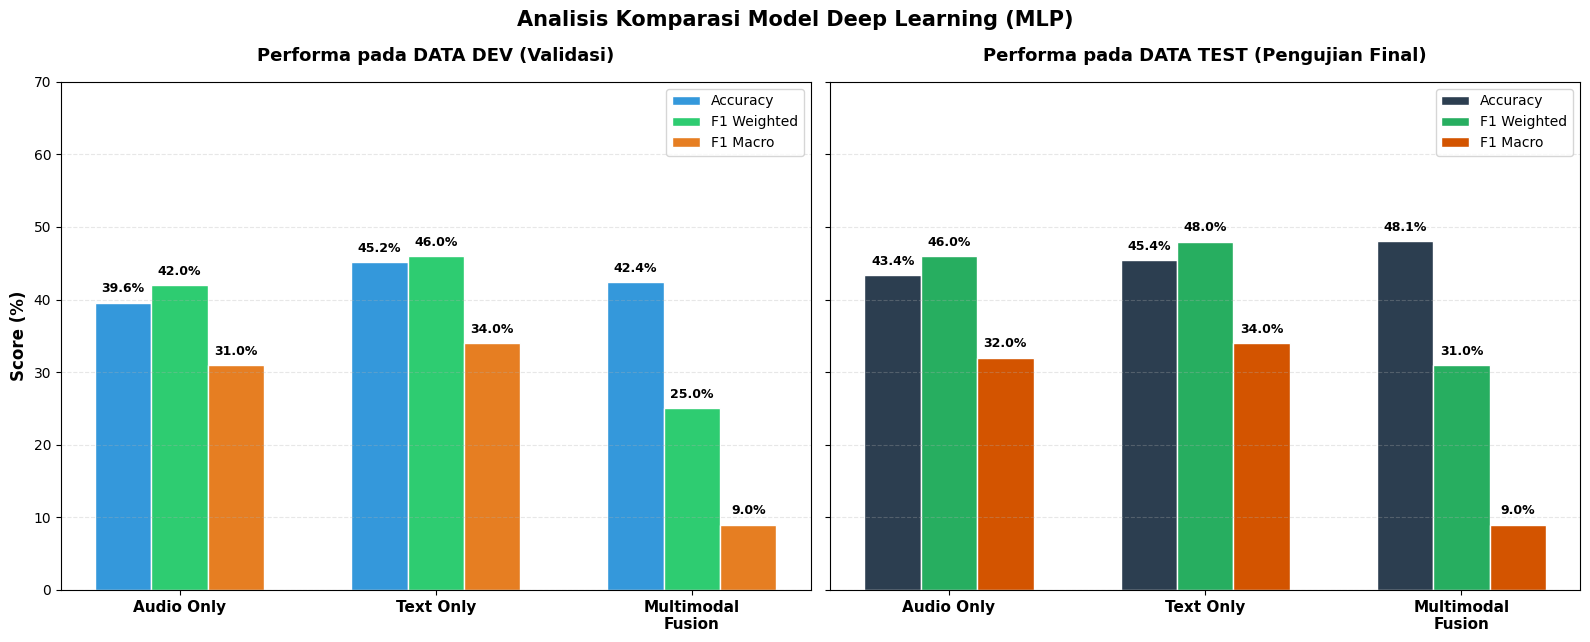

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("VISUALISASI KOMPARASI MODEL DEEP LEARNING (MLP)")

dl_results = {
    'Audio Only': {
        'dev':  {'acc': 39.59, 'f1_w': 42.0, 'f1_m': 31.0},
        'test': {'acc': 43.37, 'f1_w': 46.0, 'f1_m': 32.0}
    },
    'Text Only': {
        'dev':  {'acc': 45.18, 'f1_w': 46.0, 'f1_m': 34.0},
        'test': {'acc': 45.40, 'f1_w': 48.0, 'f1_m': 34.0}
    },
    'Multimodal\nFusion': {
        'dev':  {'acc': 42.38, 'f1_w': 25.0, 'f1_m': 9.0},
        'test': {'acc': 48.08, 'f1_w': 31.0, 'f1_m': 9.0}
    }
}

models = list(dl_results.keys())
x = np.arange(len(models))
width = 0.22  # Lebar batang bar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

acc_dev = [dl_results[m]['dev']['acc'] for m in models]
f1w_dev = [dl_results[m]['dev']['f1_w'] for m in models]
f1m_dev = [dl_results[m]['dev']['f1_m'] for m in models]

bars1_dev = ax1.bar(x - width, acc_dev, width, label='Accuracy', color='#3498db', edgecolor='white')
bars2_dev = ax1.bar(x,         f1w_dev, width, label='F1 Weighted', color='#2ecc71', edgecolor='white')
bars3_dev = ax1.bar(x + width, f1m_dev, width, label='F1 Macro', color='#e67e22', edgecolor='white')

ax1.set_title('Performa pada DATA DEV (Validasi)', fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11, fontweight='bold')
ax1.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1_dev, bars2_dev, bars3_dev]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 1.0, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

acc_test = [dl_results[m]['test']['acc'] for m in models]
f1w_test = [dl_results[m]['test']['f1_w'] for m in models]
f1m_test = [dl_results[m]['test']['f1_m'] for m in models]

bars1_test = ax2.bar(x - width, acc_test, width, label='Accuracy', color='#2c3e50', edgecolor='white') # Warna gelap membedakan data test
bars2_test = ax2.bar(x,         f1w_test, width, label='F1 Weighted', color='#27ae60', edgecolor='white')
bars3_test = ax2.bar(x + width, f1m_test, width, label='F1 Macro', color='#d35400', edgecolor='white')

ax2.set_title('Performa pada DATA TEST (Pengujian Final)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Tulis angka di atas bar Test
for bars in [bars1_test, bars2_test, bars3_test]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 1.0, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, 70)
ax1.legend(loc='upper right', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.suptitle('Analisis Komparasi Model Deep Learning (MLP)',
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
save_path = '/content/mlp_model_comparison.png'
plt.savefig(save_path, dpi=150)
plt.show()